# 02 Analysis and Figure Generation

This notebook calculates rainfall climatology, annual and seasonal rainfall indices, trend summaries, and manuscript figures for the PAGASA Science Garden rainfall trend analysis.

This notebook uses the prepared daily dataset generated by `01_data_preparation.ipynb`.

Main outputs:

1. Monthly rainfall climatology and TC-proximity rainfall fractions.
2. Annual rainfall indices and trends.
3. November–April seasonal rainfall indices and trends.
4. May–October seasonal rainfall indices and trends.
5. Manuscript figures and tables.
6. Supplementary trend and sensitivity outputs.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import linregress, norm, t

In [2]:
PROJECT_DIR = Path(".").resolve()

OUTPUT_DIR = PROJECT_DIR / "output"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
INTERMEDIATE_DIR = OUTPUT_DIR / "intermediate"

SUPP_FIGURE_DIR = FIGURE_DIR / "supplementary"
SUPP_TABLE_DIR = TABLE_DIR / "supplementary"

for path in [FIGURE_DIR, TABLE_DIR, SUPP_FIGURE_DIR, SUPP_TABLE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

PREPARED_PKL_PATH = INTERMEDIATE_DIR / "science_garden_daily_prepared.pkl"
PREPARED_CSV_PATH = INTERMEDIATE_DIR / "science_garden_daily_prepared.csv"

# Main manuscript figures
FIGURE_01_PATH = FIGURE_DIR / "figure_01_climatology.png"
FIGURE_02_PATH = FIGURE_DIR / "figure_02_annual_trends.png"
FIGURE_03_PATH = FIGURE_DIR / "figure_03_nov_apr_trends.png"
FIGURE_04_PATH = FIGURE_DIR / "figure_04_may_oct_trends.png"

# Main manuscript tables
TABLE_01_PATH = TABLE_DIR / "table_01_index_definitions.csv"
TABLE_02_PATH = TABLE_DIR / "table_02_selected_trends.csv"

# Supplementary outputs
SUPP_TABLE_S1_PATH = SUPP_TABLE_DIR / "supplementary_table_s1_full_trends.csv"

In [3]:
# -----------------------------
# Station and data settings
# -----------------------------
SCI_GARDEN_LAT = 14.65
SCI_GARDEN_LON = 121.05

CLIM_START = 1991
CLIM_END = 2020

WET_DAY_THRESHOLD = 1.0
MIN_VALID_FRACTION = 0.90

TC_FILTER_COL = "tc_1000km"

# -----------------------------
# Seasonal definitions
# -----------------------------
# Type I-style split based on Science Garden climatology
DRY_MONTHS = [11, 12, 1, 2, 3, 4]
WET_MONTHS = [5, 6, 7, 8, 9, 10]

DRY_SEASON_LABEL = "Dry season (Nov-Apr)"
WET_SEASON_LABEL = "Wet season (May-Oct)"

SEASON_ORDER = [DRY_SEASON_LABEL, WET_SEASON_LABEL]

# -----------------------------
# Plot settings
# -----------------------------
FIGURE_DPI = 300

PANEL_WIDTH = 3.3
PANEL_HEIGHT = 2.25

ROLLING_WINDOW = 10
SHOW_RUNNING_MEAN = True

MONTH_LABELS = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

In [4]:
INDEX_METADATA = {
    "PRCPTOT": {
        "name": "Wet-day rainfall total",
        "unit": "mm",
        "definition": "Total rainfall from wet days, where wet days are defined as rainfall >= 1.0 mm.",
        "interpretation": "Seasonal or annual rainfall accumulation from wet days.",
    },
    "WD": {
        "name": "Wet days",
        "unit": "days",
        "definition": "Number of days with rainfall >= 1.0 mm.",
        "interpretation": "Rainfall occurrence frequency.",
    },
    "WD_RATE": {
        "name": "Wet-day fraction",
        "unit": "fraction",
        "definition": "Wet days divided by eligible valid days.",
        "interpretation": "Fraction of valid days with rainfall >= 1.0 mm.",
    },
    "SDII": {
        "name": "Simple daily intensity index",
        "unit": "mm wet-day-1",
        "definition": "Wet-day rainfall total divided by number of wet days.",
        "interpretation": "Mean rainfall intensity on wet days.",
    },
    "R20mm": {
        "name": "Heavy precipitation days",
        "unit": "days",
        "definition": "Number of days with rainfall >= 20 mm.",
        "interpretation": "ETCCDI heavy precipitation day frequency.",
    },
    "R50mm": {
        "name": "Days with rainfall >= 50 mm",
        "unit": "days",
        "definition": "Number of days with rainfall >= 50 mm.",
        "interpretation": "Moderate-heavy rainfall frequency using a fixed local threshold.",
    },
    "R100mm": {
        "name": "Days with rainfall >= 100 mm",
        "unit": "days",
        "definition": "Number of days with rainfall >= 100 mm.",
        "interpretation": "Very heavy daily rainfall frequency.",
    },
    "RX1day": {
        "name": "Maximum 1-day rainfall",
        "unit": "mm",
        "definition": "Maximum daily rainfall within the period.",
        "interpretation": "Largest single-day rainfall total.",
    },
    "RX5day": {
        "name": "Maximum 5-day rainfall",
        "unit": "mm",
        "definition": "Maximum consecutive 5-day rainfall total within the period.",
        "interpretation": "Largest multi-day rainfall accumulation.",
    },
    "CDD": {
        "name": "Maximum consecutive dry days",
        "unit": "days",
        "definition": "Maximum number of consecutive days with rainfall < 1.0 mm.",
        "interpretation": "Dry-spell persistence.",
    },
    "DD_RATE": {
        "name": "Dry-day fraction",
        "unit": "fraction",
        "definition": "Dry days divided by eligible valid days.",
        "interpretation": "Fraction of valid days with rainfall < 1.0 mm.",
    },
    "MEAN_DRY_SPELL_LENGTH": {
        "name": "Mean dry-spell length",
        "unit": "days",
        "definition": "Mean length of consecutive dry-day runs.",
        "interpretation": "Typical dry-spell duration.",
    },
    "TOTAL_DRY_SPELL_DAYS_GE7": {
        "name": "Total days in dry spells >= 7 days",
        "unit": "days",
        "definition": "Total number of days belonging to dry spells lasting at least 7 days.",
        "interpretation": "Cumulative seasonal exposure to prolonged dry spells.",
    },
}

# Main manuscript figure indices
FIGURE_02_INDICES = ["PRCPTOT", "WD", "R20mm", "R50mm", "RX1day"]
FIGURE_03_INDICES = ["PRCPTOT", "WD_RATE", "R20mm", "CDD"]
FIGURE_04_INDICES = ["PRCPTOT", "WD_RATE", "R20mm", "R50mm", "RX1day"]

# Main table indices
TABLE_02_INDICES = ["PRCPTOT", "WD", "WD_RATE", "R20mm", "R50mm", "RX1day", "CDD"]

# Full trend table indices
FULL_TREND_INDICES = [
    "PRCPTOT",
    "WD",
    "WD_RATE",
    "SDII",
    "R20mm",
    "R50mm",
    "R100mm",
    "RX1day",
    "RX5day",
    "DD_RATE",
    "CDD",
    "MEAN_DRY_SPELL_LENGTH",
    "TOTAL_DRY_SPELL_DAYS_GE7",
]

In [5]:
if PREPARED_PKL_PATH.exists():
    df = pd.read_pickle(PREPARED_PKL_PATH)
elif PREPARED_CSV_PATH.exists():
    df = pd.read_csv(PREPARED_CSV_PATH, parse_dates=["DATE"])
else:
    raise FileNotFoundError(
        "Prepared dataset not found. Please run 01_data_preparation.ipynb first."
    )

df = df.copy()

if "DATE" not in df.columns:
    raise ValueError("Prepared dataset must contain a DATE column.")

df["DATE"] = pd.to_datetime(df["DATE"])
df = df.sort_values("DATE").reset_index(drop=True)

df["YEAR"] = df["DATE"].dt.year
df["MONTH"] = df["DATE"].dt.month
df["DAY"] = df["DATE"].dt.day

df["RAINFALL"] = pd.to_numeric(df["RAINFALL"], errors="coerce")

if TC_FILTER_COL not in df.columns:
    raise ValueError(f"{TC_FILTER_COL} not found in prepared dataset.")

df[TC_FILTER_COL] = df[TC_FILTER_COL].fillna(False).astype(bool)

print("Loaded prepared daily dataset")
print("-----------------------------")
print(f"Rows: {len(df):,}")
print(f"Date range: {df['DATE'].min().date()} to {df['DATE'].max().date()}")
print(f"Valid rainfall days: {df['RAINFALL'].notna().sum():,}")
print(f"Trace days: {df['RAINFALL_TRACE'].sum():,}" if "RAINFALL_TRACE" in df.columns else "Trace column not found")
print(f"Days with TC within 1000 km: {df[TC_FILTER_COL].sum():,}")

display(df.head())

Loaded prepared daily dataset
-----------------------------
Rows: 23,741
Date range: 1961-01-01 to 2025-12-31
Valid rainfall days: 23,302
Trace days: 627
Days with TC within 1000 km: 4,767


,DATE,YEAR,MONTH,DAY,RAINFALL,TMAX,TMIN,RH,WIND_SPEED,WIND_DIRECTION,...,tc_lon_nearest,tc_250km,tc_count_250km,tc_sids_250km,tc_500km,tc_count_500km,tc_sids_500km,tc_1000km,tc_count_1000km,tc_sids_1000km
0,1961-01-01,1961,1,1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,False,0,<NA>,False,0,<NA>,False,0,<NA>
1,1961-01-02,1961,1,2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,False,0,<NA>,False,0,<NA>,False,0,<NA>
2,1961-01-03,1961,1,3,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,False,0,<NA>,False,0,<NA>,False,0,<NA>
3,1961-01-04,1961,1,4,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,False,0,<NA>,False,0,<NA>,False,0,<NA>
4,1961-01-05,1961,1,5,0.0,29.7,18.2,75.0,2.0,90.0,...,NaN,False,0,<NA>,False,0,<NA>,False,0,<NA>


In [6]:
required_columns = [
    "DATE",
    "YEAR",
    "MONTH",
    "DAY",
    "RAINFALL",
    TC_FILTER_COL,
]

missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

checks = {
    "one_row_per_day": df["DATE"].is_unique,
    "date_is_monotonic": df["DATE"].is_monotonic_increasing,
    "no_negative_cleaned_rainfall": not (
        df["RAINFALL"].notna() & (df["RAINFALL"] < 0)
    ).any(),
    "tc_filter_is_boolean": df[TC_FILTER_COL].dtype == bool,
}

print("Validation checks")
print("-----------------")
for key, value in checks.items():
    print(f"{key}: {value}")

if not all(checks.values()):
    raise ValueError("One or more validation checks failed.")

Validation checks
-----------------
one_row_per_day: True
date_is_monotonic: True
no_negative_cleaned_rainfall: True
tc_filter_is_boolean: True


In [7]:
analysis_df = df.copy()
# analysis_df = df[df['YEAR'] > 1981].copy()

# df[df['column_name'] > threshold]

# Rainfall subsets
analysis_df["RAINFALL_all"] = analysis_df["RAINFALL"]
analysis_df["RAINFALL_non_tc_1000km"] = analysis_df["RAINFALL"].where(
    ~analysis_df[TC_FILTER_COL],
    np.nan
)

def assign_season(month):
    """
    Assign Type I-style rainfall season.
    """
    if month in DRY_MONTHS:
        return DRY_SEASON_LABEL
    elif month in WET_MONTHS:
        return WET_SEASON_LABEL
    else:
        return np.nan


def assign_season_year(row):
    """
    Assign season year.

    Nov-Apr season year Y = Nov-Dec of Y-1 plus Jan-Apr of Y.
    May-Oct season year Y = May-Oct of Y.
    """
    month = row["MONTH"]
    year = row["YEAR"]
    season = row["SEASON"]
    
    if season == DRY_SEASON_LABEL and month in [11, 12]:
        return year + 1
    else:
        return year


analysis_df["SEASON"] = analysis_df["MONTH"].apply(assign_season)
analysis_df["SEASON_YEAR"] = analysis_df.apply(assign_season_year, axis=1)

analysis_df["SEASON"] = pd.Categorical(
    analysis_df["SEASON"],
    categories=SEASON_ORDER,
    ordered=True
)

display(
    analysis_df[
        [
            "DATE",
            "YEAR",
            "MONTH",
            "SEASON_YEAR",
            "SEASON",
            "RAINFALL",
            "RAINFALL_all",
            "RAINFALL_non_tc_1000km",
            TC_FILTER_COL,
        ]
    ].head(20)
)

,DATE,YEAR,MONTH,SEASON_YEAR,SEASON,RAINFALL,RAINFALL_all,RAINFALL_non_tc_1000km,tc_1000km
0,1961-01-01,1961,1,1961,Dry season (Nov-Apr),NaN,NaN,NaN,False
1,1961-01-02,1961,1,1961,Dry season (Nov-Apr),NaN,NaN,NaN,False
2,1961-01-03,1961,1,1961,Dry season (Nov-Apr),NaN,NaN,NaN,False
3,1961-01-04,1961,1,1961,Dry season (Nov-Apr),NaN,NaN,NaN,False
4,1961-01-05,1961,1,1961,Dry season (Nov-Apr),0.0,0.0,0.0,False
5,1961-01-06,1961,1,1961,Dry season (Nov-Apr),0.0,0.0,0.0,False
6,1961-01-07,1961,1,1961,Dry season (Nov-Apr),0.0,0.0,0.0,False
7,1961-01-08,1961,1,1961,Dry season (Nov-Apr),0.0,0.0,0.0,False
8,1961-01-09,1961,1,1961,Dry season (Nov-Apr),0.0,0.0,0.0,False
9,1961-01-10,1961,1,1961,Dry season (Nov-Apr),0.0,0.0,0.0,False


In [8]:
def expected_days_in_year(year):
    return pd.Timestamp(year=int(year), month=12, day=31).dayofyear


def expected_days_in_month(year, month):
    return pd.Timestamp(year=int(year), month=int(month), day=1).days_in_month


def expected_days_in_season(season_year, season):
    """
    Expected number of days in each Type I-style season.

    Nov-Apr season year Y = Nov 1 of Y-1 to Apr 30 of Y.
    May-Oct season year Y = May 1 to Oct 31 of Y.
    """
    season_year = int(season_year)
    
    if season == DRY_SEASON_LABEL:
        dates = pd.date_range(
            start=f"{season_year - 1}-11-01",
            end=f"{season_year}-04-30",
            freq="D",
        )
    elif season == WET_SEASON_LABEL:
        dates = pd.date_range(
            start=f"{season_year}-05-01",
            end=f"{season_year}-10-31",
            freq="D",
        )
    else:
        return np.nan
    
    return len(dates)

## Monthly rainfall climatology and TC-proximity rainfall fraction

This section calculates the 1991–2020 monthly rainfall climatology at PAGASA Science Garden.

Monthly rainfall totals are first calculated for each year and month, then averaged over the climatological normal period. Rainfall is also partitioned into:

- rainfall on days with no TC centre within 1000 km;
- rainfall on days with a TC centre within 1000 km.

This is a TC-proximity classification, not formal TC rainfall attribution.

In [9]:
clim_df = analysis_df.copy()

clim_df["RAINFALL_TC1000"] = clim_df["RAINFALL"].where(
    clim_df[TC_FILTER_COL],
    0.0
)

clim_df["RAINFALL_NONTC1000"] = clim_df["RAINFALL"].where(
    ~clim_df[TC_FILTER_COL],
    0.0
)

# Preserve missing rainfall as missing in both partitions
missing_rain = clim_df["RAINFALL"].isna()
clim_df.loc[missing_rain, ["RAINFALL_TC1000", "RAINFALL_NONTC1000"]] = np.nan

display(
    clim_df[
        [
            "DATE",
            "YEAR",
            "MONTH",
            "RAINFALL",
            TC_FILTER_COL,
            "RAINFALL_TC1000",
            "RAINFALL_NONTC1000",
        ]
    ].head()
)

,DATE,YEAR,MONTH,RAINFALL,tc_1000km,RAINFALL_TC1000,RAINFALL_NONTC1000
0,1961-01-01,1961,1,NaN,False,NaN,NaN
1,1961-01-02,1961,1,NaN,False,NaN,NaN
2,1961-01-03,1961,1,NaN,False,NaN,NaN
3,1961-01-04,1961,1,NaN,False,NaN,NaN
4,1961-01-05,1961,1,0.0,False,0.0,0.0


In [10]:
def sum_with_min_count(x):
    """
    Sum while returning NaN if all values are missing.
    """
    return x.sum(min_count=1)


monthly_totals_by_year = (
    clim_df
    .groupby(["YEAR", "MONTH"])
    .agg(
        monthly_rainfall_mm=("RAINFALL", sum_with_min_count),
        monthly_tc1000_rainfall_mm=("RAINFALL_TC1000", sum_with_min_count),
        monthly_nontc1000_rainfall_mm=("RAINFALL_NONTC1000", sum_with_min_count),
        valid_days=("RAINFALL", "count"),
        tc1000_days=(TC_FILTER_COL, "sum"),
    )
    .reset_index()
)

monthly_totals_by_year["expected_days"] = monthly_totals_by_year.apply(
    lambda row: expected_days_in_month(row["YEAR"], row["MONTH"]),
    axis=1
)

monthly_totals_by_year["valid_fraction"] = (
    monthly_totals_by_year["valid_days"]
    / monthly_totals_by_year["expected_days"]
)

monthly_totals_by_year["is_valid_month"] = (
    monthly_totals_by_year["valid_fraction"] >= MIN_VALID_FRACTION
)

rainfall_cols = [
    "monthly_rainfall_mm",
    "monthly_tc1000_rainfall_mm",
    "monthly_nontc1000_rainfall_mm",
]

monthly_totals_by_year.loc[
    ~monthly_totals_by_year["is_valid_month"],
    rainfall_cols
] = np.nan

display(monthly_totals_by_year.head())

,YEAR,MONTH,monthly_rainfall_mm,monthly_tc1000_rainfall_mm,monthly_nontc1000_rainfall_mm,valid_days,tc1000_days,expected_days,valid_fraction,is_valid_month
0,1961,1,NaN,NaN,NaN,27,0,31,0.870968,False
1,1961,2,7.6,0.0,7.6,28,0,28,1.000000,True
2,1961,3,63.6,0.0,63.6,31,0,31,1.000000,True
3,1961,4,38.8,0.0,38.8,30,0,30,1.000000,True
4,1961,5,124.8,84.5,40.3,31,11,31,1.000000,True


In [11]:
monthly_clim_source = monthly_totals_by_year[
    (monthly_totals_by_year["YEAR"] >= CLIM_START)
    & (monthly_totals_by_year["YEAR"] <= CLIM_END)
].copy()

monthly_climatology = (
    monthly_clim_source
    .groupby("MONTH")
    .agg(
        mean_monthly_rainfall_mm=("monthly_rainfall_mm", "mean"),
        median_monthly_rainfall_mm=("monthly_rainfall_mm", "median"),
        std_monthly_rainfall_mm=("monthly_rainfall_mm", "std"),
        mean_tc1000_rainfall_mm=("monthly_tc1000_rainfall_mm", "mean"),
        mean_nontc1000_rainfall_mm=("monthly_nontc1000_rainfall_mm", "mean"),
        mean_tc1000_days=("tc1000_days", "mean"),
        n_valid_years=("monthly_rainfall_mm", "count"),
    )
    .reset_index()
)

monthly_climatology["month_label"] = monthly_climatology["MONTH"].apply(
    lambda m: MONTH_LABELS[int(m) - 1]
)

monthly_climatology["tc1000_fraction_of_rainfall"] = (
    monthly_climatology["mean_tc1000_rainfall_mm"]
    / monthly_climatology["mean_monthly_rainfall_mm"]
)

monthly_climatology["nontc1000_fraction_of_rainfall"] = (
    monthly_climatology["mean_nontc1000_rainfall_mm"]
    / monthly_climatology["mean_monthly_rainfall_mm"]
)

monthly_climatology["tc1000_fraction_percent"] = (
    monthly_climatology["tc1000_fraction_of_rainfall"] * 100
)

display(monthly_climatology)

,MONTH,mean_monthly_rainfall_mm,median_monthly_rainfall_mm,std_monthly_rainfall_mm,mean_tc1000_rainfall_mm,mean_nontc1000_rainfall_mm,mean_tc1000_days,n_valid_years,month_label,tc1000_fraction_of_rainfall,nontc1000_fraction_of_rainfall,tc1000_fraction_percent
0,1,27.093333,17.30,32.020650,2.850000,24.243333,1.300000,30,Jan,0.105192,0.894808,10.519193
1,2,24.410000,8.30,34.064790,4.683333,19.726667,0.766667,30,Feb,0.191861,0.808139,19.186126
2,3,32.913333,14.15,46.586765,1.713333,31.200000,1.166667,30,Mar,0.052056,0.947944,5.205590
3,4,41.640000,30.05,41.585886,7.236667,34.403333,2.100000,30,Apr,0.173791,0.826209,17.379123
4,5,211.946667,192.50,135.790893,69.116667,142.830000,3.866667,30,May,0.326104,0.673896,32.610405
5,6,322.710000,301.15,163.055189,128.740000,193.970000,5.766667,30,Jun,0.398934,0.601066,39.893403
6,7,516.606667,507.90,259.108791,251.260000,265.346667,9.333333,30,Jul,0.486366,0.513634,48.636616
7,8,568.546667,520.40,235.264384,199.666667,368.880000,10.233333,30,Aug,0.351188,0.648812,35.118782
8,9,500.346667,447.05,186.163667,247.606667,252.740000,10.866667,30,Sep,0.494870,0.505130,49.487022
9,10,283.573333,274.50,115.930309,136.676667,146.896667,9.600000,30,Oct,0.481980,0.518020,48.197997


In [12]:
def climatological_fraction_for_months(months, label):
    subset = monthly_climatology[
        monthly_climatology["MONTH"].isin(months)
    ].copy()
    
    total_rainfall = subset["mean_monthly_rainfall_mm"].sum()
    tc1000_rainfall = subset["mean_tc1000_rainfall_mm"].sum()
    nontc1000_rainfall = subset["mean_nontc1000_rainfall_mm"].sum()
    
    return {
        "period": label,
        "months": ", ".join([MONTH_LABELS[m - 1] for m in months]),
        "mean_total_rainfall_mm": total_rainfall,
        "mean_tc1000_rainfall_mm": tc1000_rainfall,
        "mean_nontc1000_rainfall_mm": nontc1000_rainfall,
        "tc1000_fraction": tc1000_rainfall / total_rainfall,
        "tc1000_fraction_percent": 100 * tc1000_rainfall / total_rainfall,
    }


climatology_fraction_summary = pd.DataFrame([
    climatological_fraction_for_months(DRY_MONTHS, DRY_SEASON_LABEL),
    climatological_fraction_for_months(WET_MONTHS, WET_SEASON_LABEL),
    climatological_fraction_for_months([6, 7, 8, 9, 10, 11, 12], "Jun-Dec"),
    climatological_fraction_for_months(range(1, 13), "Annual"),
])

display(climatology_fraction_summary)

,period,months,mean_total_rainfall_mm,mean_tc1000_rainfall_mm,mean_nontc1000_rainfall_mm,tc1000_fraction,tc1000_fraction_percent
0,Dry season (Nov-Apr),"Nov, Dec, Jan, Feb, Mar, Apr",381.996667,124.990000,257.006667,0.327202,32.720181
1,Wet season (May-Oct),"May, Jun, Jul, Aug, Sep, Oct",2403.730000,1033.066667,1370.663333,0.429777,42.977650
2,Jun-Dec,"Jun, Jul, Aug, Sep, Oct, Nov, Dec",2447.723333,1072.456667,1375.266667,0.438145,43.814456
3,Annual,"Jan, Feb, Mar, Apr, May, Jun, Jul, Aug, Sep, O...",2785.726667,1158.056667,1627.670000,0.415711,41.571080


In [13]:
MONTHLY_CLIMATOLOGY_PATH = TABLE_DIR / f"science_garden_monthly_climatology_{CLIM_START}_{CLIM_END}.csv"
CLIMATOLOGY_FRACTION_SUMMARY_PATH = TABLE_DIR / f"science_garden_tc1000_fraction_summary_{CLIM_START}_{CLIM_END}.csv"

monthly_climatology.to_csv(MONTHLY_CLIMATOLOGY_PATH, index=False)
climatology_fraction_summary.to_csv(CLIMATOLOGY_FRACTION_SUMMARY_PATH, index=False)

print("Saved climatology tables:")
print(f"- {MONTHLY_CLIMATOLOGY_PATH}")
print(f"- {CLIMATOLOGY_FRACTION_SUMMARY_PATH}")

Saved climatology tables:
- /home/jupyter-bbr/source/science-garden-rainfall-trends/output/tables/science_garden_monthly_climatology_1991_2020.csv
- /home/jupyter-bbr/source/science-garden-rainfall-trends/output/tables/science_garden_tc1000_fraction_summary_1991_2020.csv


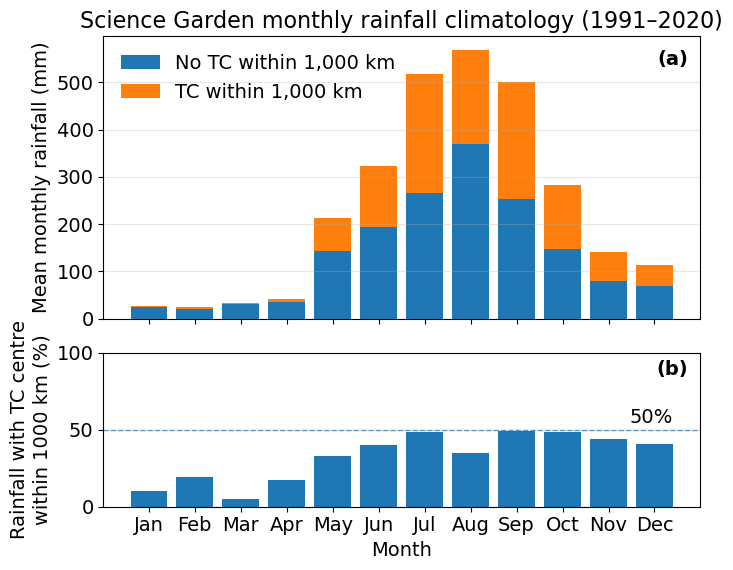

Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/figures/figure_01_climatology_tc_fraction.png


In [80]:
FIGURE_01_CLIMATOLOGY_ONLY_PATH = (
    FIGURE_DIR / "figure_01_climatology_tc_fraction.png"
)

# ------------------------------------------------------------
# Font sizes
# ------------------------------------------------------------

TITLE_FS = 16
LABEL_FS = 14
TICK_FS = 14
LEGEND_FS = 14
PANEL_FS = 14
ANNOTATION_FS = 14


fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(7.2, 5.8),
    sharex=True,
    gridspec_kw={"height_ratios": [2.2, 1.2]}
)

x = np.arange(len(monthly_climatology))

month_labels = monthly_climatology["month_label"]
nontc_vals = monthly_climatology["mean_nontc1000_rainfall_mm"]
tc_vals = monthly_climatology["mean_tc1000_rainfall_mm"]
fraction_vals = monthly_climatology["tc1000_fraction_percent"]


# ------------------------------------------------------------
# Helper for panel labels
# ------------------------------------------------------------

def add_panel_label(ax, label):
    ax.text(
        0.98,
        0.95,
        label,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=PANEL_FS,
        fontweight="bold",
        bbox={
            "boxstyle": "round,pad=0.18",
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.75,
        },
    )


# ------------------------------------------------------------
# Panel a: Stacked rainfall climatology
# ------------------------------------------------------------

ax = axes[0]

ax.bar(
    x,
    nontc_vals,
    label="No TC within 1,000 km"
)

ax.bar(
    x,
    tc_vals,
    bottom=nontc_vals,
    label="TC within 1,000 km"
)

ax.set_ylabel(
    "Mean monthly rainfall (mm)",
    fontsize=LABEL_FS
)

ax.set_title(
    f"Science Garden monthly rainfall climatology "
    f"({CLIM_START}–{CLIM_END})",
    fontsize=TITLE_FS
)

ax.tick_params(
    axis="both",
    labelsize=TICK_FS
)

ax.grid(
    axis="y",
    alpha=0.3
)

ax.legend(
    frameon=False,
    fontsize=LEGEND_FS,
    loc="upper left"
)

add_panel_label(
    ax,
    "(a)"
)


# ------------------------------------------------------------
# Panel b: TC-proximity rainfall fraction
# ------------------------------------------------------------

ax = axes[1]

ax.bar(
    x,
    fraction_vals
)

ax.axhline(
    50,
    linewidth=1,
    linestyle="--",
    alpha=0.7
)

ax.set_ylabel(
    "Rainfall with TC centre\nwithin 1000 km (%)",
    fontsize=LABEL_FS
)

ax.set_xlabel(
    "Month",
    fontsize=LABEL_FS
)

ax.set_ylim(
    0,
    100
)

ax.grid(
    axis="y",
    alpha=0.3
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    month_labels,
    fontsize=TICK_FS
)

ax.tick_params(
    axis="y",
    labelsize=TICK_FS
)

ax.text(
    11.4,
    52,
    "50%",
    ha="right",
    va="bottom",
    fontsize=ANNOTATION_FS
)

add_panel_label(
    ax,
    "(b)"
)


plt.tight_layout()

plt.savefig(
    FIGURE_01_CLIMATOLOGY_ONLY_PATH,
    dpi=FIGURE_DPI,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved: {FIGURE_01_CLIMATOLOGY_ONLY_PATH}"
)

In [15]:
df.head()

,DATE,YEAR,MONTH,DAY,RAINFALL,TMAX,TMIN,RH,WIND_SPEED,WIND_DIRECTION,...,tc_lon_nearest,tc_250km,tc_count_250km,tc_sids_250km,tc_500km,tc_count_500km,tc_sids_500km,tc_1000km,tc_count_1000km,tc_sids_1000km
0,1961-01-01,1961,1,1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,False,0,<NA>,False,0,<NA>,False,0,<NA>
1,1961-01-02,1961,1,2,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,False,0,<NA>,False,0,<NA>,False,0,<NA>
2,1961-01-03,1961,1,3,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,False,0,<NA>,False,0,<NA>,False,0,<NA>
3,1961-01-04,1961,1,4,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,False,0,<NA>,False,0,<NA>,False,0,<NA>
4,1961-01-05,1961,1,5,0.0,29.7,18.2,75.0,2.0,90.0,...,NaN,False,0,<NA>,False,0,<NA>,False,0,<NA>


In [16]:
# ============================================================
# Wet-season TC-day climatology (1991–2020)
# ============================================================

science_garden_daily_prepared = df.copy()


wet_season = science_garden_daily_prepared.loc[
    (
        science_garden_daily_prepared["YEAR"]
        .between(CLIM_START, CLIM_END)
    )
    &
    (
        science_garden_daily_prepared["MONTH"]
        .between(5, 10)
    )
].copy()

annual_tc_days = (
    wet_season
    .groupby("YEAR")["tc_1000km"]
    .sum()
)

annual_total_days = (
    wet_season
    .groupby("YEAR")
    .size()
)

tc_day_summary = pd.DataFrame({
    "TC_days": annual_tc_days,
    "Total_days": annual_total_days,
})

tc_day_summary["TC_fraction_percent"] = (
    100
    * tc_day_summary["TC_days"]
    / tc_day_summary["Total_days"]
)

display(tc_day_summary)

print(f"Mean TC days per May–Oct season: "
      f"{tc_day_summary['TC_days'].mean():.1f}")

print(f"Mean May–Oct days: "
      f"{tc_day_summary['Total_days'].mean():.1f}")

print(f"Mean percentage of days with TC centre within 1000 km: "
      f"{tc_day_summary['TC_fraction_percent'].mean():.1f}%")

,TC_days,Total_days,TC_fraction_percent
YEAR,,,
1991,61,184,33.152174
1992,59,184,32.065217
1993,64,184,34.782609
1994,71,184,38.586957
1995,81,184,44.021739
1996,56,184,30.434783
1997,48,184,26.086957
1998,46,184,25.000000
1999,48,184,26.086957


Mean TC days per May–Oct season: 49.7
Mean May–Oct days: 184.0
Mean percentage of days with TC centre within 1000 km: 27.0%


## Table 1. Principal rainfall index definitions

This section generates the manuscript table describing the principal rainfall indices used in the analysis.

The table is intentionally limited to the main indices discussed in the manuscript. The full set of calculated indices can be retained in the supplementary trend table.

In [17]:
TABLE_01_INDICES = [
    "PRCPTOT",
    "WD",
    "WD_RATE",
    "SDII",
    "R20mm",
    "R50mm",
    "RX1day",
    "RX5day",
    "CDD",
]

In [18]:
table_01_index_definitions = pd.DataFrame([
    {
        "index": index,
        "name": INDEX_METADATA[index]["name"],
        "definition": INDEX_METADATA[index]["definition"],
        "unit": INDEX_METADATA[index]["unit"],
        "interpretation": INDEX_METADATA[index]["interpretation"],
    }
    for index in TABLE_01_INDICES
])

display(table_01_index_definitions)

,index,name,definition,unit,interpretation
0,PRCPTOT,Wet-day rainfall total,"Total rainfall from wet days, where wet days a...",mm,Seasonal or annual rainfall accumulation from ...
1,WD,Wet days,Number of days with rainfall >= 1.0 mm.,days,Rainfall occurrence frequency.
2,WD_RATE,Wet-day fraction,Wet days divided by eligible valid days.,fraction,Fraction of valid days with rainfall >= 1.0 mm.
3,SDII,Simple daily intensity index,Wet-day rainfall total divided by number of we...,mm wet-day-1,Mean rainfall intensity on wet days.
4,R20mm,Heavy precipitation days,Number of days with rainfall >= 20 mm.,days,ETCCDI heavy precipitation day frequency.
5,R50mm,Days with rainfall >= 50 mm,Number of days with rainfall >= 50 mm.,days,Moderate-heavy rainfall frequency using a fixe...
6,RX1day,Maximum 1-day rainfall,Maximum daily rainfall within the period.,mm,Largest single-day rainfall total.
7,RX5day,Maximum 5-day rainfall,Maximum consecutive 5-day rainfall total withi...,mm,Largest multi-day rainfall accumulation.
8,CDD,Maximum consecutive dry days,Maximum number of consecutive days with rainfa...,days,Dry-spell persistence.


In [19]:
table_01_index_definitions.to_csv(TABLE_01_PATH, index=False)

print("Saved Table 1:")
print(f"- {TABLE_01_PATH}")

Saved Table 1:
- /home/jupyter-bbr/source/science-garden-rainfall-trends/output/tables/table_01_index_definitions.csv


## Annual and seasonal rainfall indices

This section calculates annual and seasonal rainfall indices for two rainfall subsets:

1. `all_days`: all valid rainfall observations;
2. `non_tc_1000km`: days without a TC centre within 1000 km.

The non-TC subset is created by masking TC-proximity days as missing. Therefore, for spell-based indices in the non-TC subset, TC-proximity days are excluded and break consecutive-day runs.

In [20]:
def get_run_lengths(flag_series):
    """
    Return lengths of consecutive True values.
    
    False and missing values break a run.
    """
    arr = pd.Series(flag_series).fillna(False).astype(bool).to_numpy()
    
    run_lengths = []
    current_length = 0
    
    for value in arr:
        if value:
            current_length += 1
        else:
            if current_length > 0:
                run_lengths.append(current_length)
            current_length = 0
    
    if current_length > 0:
        run_lengths.append(current_length)
    
    return run_lengths


def rx5day_calendar(rr):
    """
    Maximum consecutive 5-day rainfall total.
    
    Requires all five days in the rolling window to be valid.
    """
    rr = pd.Series(rr).astype(float)
    return rr.rolling(window=5, min_periods=5).sum().max()


def calculate_rainfall_indices_for_period(rr, wet_threshold=1.0):
    """
    Calculate rainfall indices for a single annual or seasonal period.
    
    rr should already represent the desired rainfall subset:
    - all valid days; or
    - non-TC days, with TC-proximity days masked as NaN.
    """
    rr = pd.Series(rr).astype(float)
    
    eligible_days = rr.notna().sum()
    
    if eligible_days == 0:
        return {
            "eligible_days": 0,
            "PRCPTOT": np.nan,
            "WD": np.nan,
            "WD_RATE": np.nan,
            "SDII": np.nan,
            "R20mm": np.nan,
            "R50mm": np.nan,
            "R100mm": np.nan,
            "RX1day": np.nan,
            "RX5day": np.nan,
            "DD": np.nan,
            "DD_RATE": np.nan,
            "CDD": np.nan,
            "CWD": np.nan,
            "MEAN_DRY_SPELL_LENGTH": np.nan,
            "TOTAL_DRY_SPELL_DAYS_GE7": np.nan,
        }
    
    wet = (rr >= wet_threshold) & rr.notna()
    dry = (rr < wet_threshold) & rr.notna()
    
    wet_lengths = get_run_lengths(wet)
    dry_lengths = get_run_lengths(dry)
    
    dry_lengths_ge7 = [x for x in dry_lengths if x >= 7]
    
    wd = int(wet.sum())
    dd = int(dry.sum())
    
    prcptot = rr.where(wet).sum()
    sdii = prcptot / wd if wd > 0 else np.nan
    
    return {
        "eligible_days": int(eligible_days),
        "PRCPTOT": prcptot,
        "WD": wd,
        "WD_RATE": wd / eligible_days,
        "SDII": sdii,
        "R20mm": int((rr >= 20).sum()),
        "R50mm": int((rr >= 50).sum()),
        "R100mm": int((rr >= 100).sum()),
        "RX1day": rr.max(),
        "RX5day": rx5day_calendar(rr),
        "DD": dd,
        "DD_RATE": dd / eligible_days,
        "CDD": max(dry_lengths) if len(dry_lengths) > 0 else 0,
        "CWD": max(wet_lengths) if len(wet_lengths) > 0 else 0,
        "MEAN_DRY_SPELL_LENGTH": np.mean(dry_lengths) if len(dry_lengths) > 0 else 0,
        "TOTAL_DRY_SPELL_DAYS_GE7": sum(dry_lengths_ge7) if len(dry_lengths_ge7) > 0 else 0,
    }

In [21]:
def calculate_annual_indices(data, rr_col, subset_name):
    """
    Calculate annual rainfall indices.
    
    Completeness screening uses original RAINFALL coverage, not the masked subset.
    """
    rows = []
    
    for year, g in data.groupby("YEAR"):
        g = g.sort_values("DATE").copy()
        
        rr = pd.to_numeric(g[rr_col], errors="coerce")
        rr_all = pd.to_numeric(g["RAINFALL"], errors="coerce")
        
        expected_days = expected_days_in_year(year)
        valid_days = rr_all.notna().sum()
        valid_fraction = valid_days / expected_days
        is_valid = valid_fraction >= MIN_VALID_FRACTION
        
        if is_valid:
            indices = calculate_rainfall_indices_for_period(
                rr,
                wet_threshold=WET_DAY_THRESHOLD
            )
        else:
            indices = {
                "eligible_days": rr.notna().sum(),
                "PRCPTOT": np.nan,
                "WD": np.nan,
                "WD_RATE": np.nan,
                "SDII": np.nan,
                "R20mm": np.nan,
                "R50mm": np.nan,
                "R100mm": np.nan,
                "RX1day": np.nan,
                "RX5day": np.nan,
                "DD": np.nan,
                "DD_RATE": np.nan,
                "CDD": np.nan,
                "CWD": np.nan,
                "MEAN_DRY_SPELL_LENGTH": np.nan,
                "TOTAL_DRY_SPELL_DAYS_GE7": np.nan,
            }
        
        rows.append({
            "period_type": "Annual",
            "period": "Annual",
            "subset": subset_name,
            "YEAR": year,
            "expected_days": expected_days,
            "valid_days": valid_days,
            "valid_fraction": valid_fraction,
            "is_valid": is_valid,
            **indices,
        })
    
    return pd.DataFrame(rows).sort_values(["subset", "YEAR"]).reset_index(drop=True)


annual_indices_all = calculate_annual_indices(
    data=analysis_df,
    rr_col="RAINFALL_all",
    subset_name="all_days"
)

annual_indices_non_tc = calculate_annual_indices(
    data=analysis_df,
    rr_col="RAINFALL_non_tc_1000km",
    subset_name="non_tc_1000km"
)

annual_indices = pd.concat(
    [annual_indices_all, annual_indices_non_tc],
    ignore_index=True
)

display(annual_indices.head())
display(annual_indices.tail())

,period_type,period,subset,YEAR,expected_days,valid_days,valid_fraction,is_valid,eligible_days,PRCPTOT,...,R50mm,R100mm,RX1day,RX5day,DD,DD_RATE,CDD,CWD,MEAN_DRY_SPELL_LENGTH,TOTAL_DRY_SPELL_DAYS_GE7
0,Annual,Annual,all_days,1961,365,361,0.989041,True,361,2593.2,...,12.0,4.0,128.3,394.4,223.0,0.617729,31.0,26.0,4.955556,143.0
1,Annual,Annual,all_days,1962,365,365,1.000000,True,365,2367.4,...,11.0,4.0,191.0,543.2,244.0,0.668493,40.0,10.0,5.422222,175.0
2,Annual,Annual,all_days,1963,365,365,1.000000,True,365,2257.2,...,12.0,1.0,114.3,247.5,225.0,0.616438,78.0,13.0,5.232558,141.0
3,Annual,Annual,all_days,1964,366,366,1.000000,True,366,2711.8,...,17.0,4.0,193.4,292.1,223.0,0.609290,42.0,18.0,3.982143,138.0
4,Annual,Annual,all_days,1965,365,365,1.000000,True,365,2140.6,...,8.0,2.0,159.8,263.5,238.0,0.652055,45.0,11.0,3.901639,132.0


,period_type,period,subset,YEAR,expected_days,valid_days,valid_fraction,is_valid,eligible_days,PRCPTOT,...,R50mm,R100mm,RX1day,RX5day,DD,DD_RATE,CDD,CWD,MEAN_DRY_SPELL_LENGTH,TOTAL_DRY_SPELL_DAYS_GE7
125,Annual,Annual,non_tc_1000km,2021,365,361,0.989041,True,308,1787.1,...,6.0,3.0,189.0,497.1,208.0,0.675325,16.0,15.0,4.333333,107.0
126,Annual,Annual,non_tc_1000km,2022,365,365,1.000000,True,312,1920.4,...,11.0,0.0,97.5,156.4,199.0,0.637821,22.0,8.0,3.262295,94.0
127,Annual,Annual,non_tc_1000km,2023,365,365,1.000000,True,322,2075.1,...,10.0,2.0,127.0,334.6,206.0,0.639752,21.0,8.0,4.291667,127.0
128,Annual,Annual,non_tc_1000km,2024,366,366,1.000000,True,299,1233.3,...,2.0,1.0,102.4,141.3,198.0,0.662207,32.0,10.0,4.500000,117.0
129,Annual,Annual,non_tc_1000km,2025,365,365,1.000000,True,299,2270.6,...,9.0,2.0,285.8,147.9,176.0,0.588629,37.0,7.0,4.190476,109.0


In [22]:
def calculate_seasonal_indices(data, rr_col, subset_name):
    """
    Calculate Nov-Apr and May-Oct rainfall indices.
    
    Completeness screening uses original RAINFALL coverage, not the masked subset.
    """
    rows = []
    
    for (season_year, season), g in data.groupby(["SEASON_YEAR", "SEASON"], observed=False):
        if pd.isna(season):
            continue
        
        g = g.sort_values("DATE").copy()
        
        rr = pd.to_numeric(g[rr_col], errors="coerce")
        rr_all = pd.to_numeric(g["RAINFALL"], errors="coerce")
        
        expected_days = expected_days_in_season(season_year, season)
        valid_days = rr_all.notna().sum()
        valid_fraction = valid_days / expected_days
        is_valid = valid_fraction >= MIN_VALID_FRACTION
        
        if is_valid:
            indices = calculate_rainfall_indices_for_period(
                rr,
                wet_threshold=WET_DAY_THRESHOLD
            )
        else:
            indices = {
                "eligible_days": rr.notna().sum(),
                "PRCPTOT": np.nan,
                "WD": np.nan,
                "WD_RATE": np.nan,
                "SDII": np.nan,
                "R20mm": np.nan,
                "R50mm": np.nan,
                "R100mm": np.nan,
                "RX1day": np.nan,
                "RX5day": np.nan,
                "DD": np.nan,
                "DD_RATE": np.nan,
                "CDD": np.nan,
                "CWD": np.nan,
                "MEAN_DRY_SPELL_LENGTH": np.nan,
                "TOTAL_DRY_SPELL_DAYS_GE7": np.nan,
            }
        
        rows.append({
            "period_type": "Seasonal",
            "period": season,
            "subset": subset_name,
            "YEAR": season_year,
            "SEASON_YEAR": season_year,
            "SEASON": season,
            "expected_days": expected_days,
            "valid_days": valid_days,
            "valid_fraction": valid_fraction,
            "is_valid": is_valid,
            **indices,
        })
    
    out = pd.DataFrame(rows)
    
    out["SEASON"] = pd.Categorical(
        out["SEASON"],
        categories=SEASON_ORDER,
        ordered=True
    )
    
    return (
        out
        .sort_values(["subset", "SEASON", "SEASON_YEAR"])
        .reset_index(drop=True)
    )


seasonal_indices_all = calculate_seasonal_indices(
    data=analysis_df,
    rr_col="RAINFALL_all",
    subset_name="all_days"
)

seasonal_indices_non_tc = calculate_seasonal_indices(
    data=analysis_df,
    rr_col="RAINFALL_non_tc_1000km",
    subset_name="non_tc_1000km"
)

seasonal_indices = pd.concat(
    [seasonal_indices_all, seasonal_indices_non_tc],
    ignore_index=True
)

display(seasonal_indices.head())
display(seasonal_indices.tail())

,period_type,period,subset,YEAR,SEASON_YEAR,SEASON,expected_days,valid_days,valid_fraction,is_valid,...,R50mm,R100mm,RX1day,RX5day,DD,DD_RATE,CDD,CWD,MEAN_DRY_SPELL_LENGTH,TOTAL_DRY_SPELL_DAYS_GE7
0,Seasonal,Dry season (Nov-Apr),all_days,1961,1961,Dry season (Nov-Apr),181,116,0.640884,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Seasonal,Dry season (Nov-Apr),all_days,1962,1962,Dry season (Nov-Apr),181,181,1.000000,True,...,1.0,0.0,51.6,97.1,157.0,0.867403,40.0,3.0,9.812500,137.0
2,Seasonal,Dry season (Nov-Apr),all_days,1963,1963,Dry season (Nov-Apr),181,181,1.000000,True,...,0.0,0.0,33.0,43.9,163.0,0.900552,78.0,5.0,20.375000,146.0
3,Seasonal,Dry season (Nov-Apr),all_days,1964,1964,Dry season (Nov-Apr),182,182,1.000000,True,...,0.0,0.0,44.6,73.4,154.0,0.846154,42.0,5.0,9.058824,126.0
4,Seasonal,Dry season (Nov-Apr),all_days,1965,1965,Dry season (Nov-Apr),181,181,1.000000,True,...,2.0,0.0,56.7,96.7,144.0,0.795580,45.0,7.0,7.578947,114.0


,period_type,period,subset,YEAR,SEASON_YEAR,SEASON,expected_days,valid_days,valid_fraction,is_valid,...,R50mm,R100mm,RX1day,RX5day,DD,DD_RATE,CDD,CWD,MEAN_DRY_SPELL_LENGTH,TOTAL_DRY_SPELL_DAYS_GE7
257,Seasonal,Wet season (May-Oct),non_tc_1000km,2021,2021,Wet season (May-Oct),184,184,1.0,True,...,4.0,3.0,189.0,497.1,74.0,0.510345,12.0,15.0,3.363636,28.0
258,Seasonal,Wet season (May-Oct),non_tc_1000km,2022,2022,Wet season (May-Oct),184,184,1.0,True,...,10.0,0.0,97.5,156.4,64.0,0.447552,9.0,8.0,1.882353,9.0
259,Seasonal,Wet season (May-Oct),non_tc_1000km,2023,2023,Wet season (May-Oct),184,184,1.0,True,...,10.0,2.0,127.0,334.6,64.0,0.441379,8.0,8.0,2.133333,8.0
260,Seasonal,Wet season (May-Oct),non_tc_1000km,2024,2024,Wet season (May-Oct),184,184,1.0,True,...,2.0,1.0,102.4,141.3,60.0,0.441176,8.0,10.0,2.222222,8.0
261,Seasonal,Wet season (May-Oct),non_tc_1000km,2025,2025,Wet season (May-Oct),184,184,1.0,True,...,8.0,2.0,285.8,147.9,49.0,0.362963,7.0,7.0,2.333333,21.0


In [23]:
ANNUAL_INDICES_PATH = TABLE_DIR / "annual_rainfall_indices.csv"
SEASONAL_INDICES_PATH = TABLE_DIR / "seasonal_rainfall_indices.csv"

annual_indices.to_csv(ANNUAL_INDICES_PATH, index=False)
seasonal_indices.to_csv(SEASONAL_INDICES_PATH, index=False)

print("Saved index tables:")
print(f"- {ANNUAL_INDICES_PATH}")
print(f"- {SEASONAL_INDICES_PATH}")## Trend analysis


Saved index tables:
- /home/jupyter-bbr/source/science-garden-rainfall-trends/output/tables/annual_rainfall_indices.csv
- /home/jupyter-bbr/source/science-garden-rainfall-trends/output/tables/seasonal_rainfall_indices.csv


## Trend analysis

This section estimates trends for the annual and seasonal rainfall indices.

Trend magnitude is estimated using ordinary least-squares regression and expressed per decade. The 95% confidence interval is calculated from the standard error of the OLS slope. Mann–Kendall and Theil–Sen estimates are used as non-parametric robustness checks.

Only valid annual or seasonal periods are used in trend estimation. Invalid periods have index values set to missing during the index-calculation step.

In [24]:
def format_p_value(p):
    """
    Format p-values for display.
    """
    if pd.isna(p):
        return "NA"
    if p < 0.001:
        return "<0.001"
    return f"{p:.3f}"


def classify_trend(slope, p_value, alpha=0.05):
    """
    Classify trend direction based on slope and p-value.
    """
    if pd.isna(slope) or pd.isna(p_value):
        return "no_test"
    if p_value >= alpha:
        return "not_significant"
    if slope > 0:
        return "increasing"
    if slope < 0:
        return "decreasing"
    return "not_significant"


def mann_kendall_test(y, alpha=0.05):
    """
    Original two-sided Mann-Kendall trend test with tie correction.
    """
    y = pd.Series(y).dropna().to_numpy()
    n = len(y)
    
    if n < 3:
        return {
            "mk_s": np.nan,
            "mk_var_s": np.nan,
            "mk_z": np.nan,
            "mk_p_value": np.nan,
            "mk_tau": np.nan,
            "mk_trend": "no_test",
        }
    
    s = 0
    for k in range(n - 1):
        s += np.sign(y[k + 1:] - y[k]).sum()
    
    _, counts = np.unique(y, return_counts=True)
    tie_counts = counts[counts > 1]
    
    var_s = (
        n * (n - 1) * (2 * n + 5)
        - np.sum(tie_counts * (tie_counts - 1) * (2 * tie_counts + 5))
    ) / 18
    
    if var_s == 0:
        z = 0.0
        p_value = 1.0
    else:
        if s > 0:
            z = (s - 1) / np.sqrt(var_s)
        elif s < 0:
            z = (s + 1) / np.sqrt(var_s)
        else:
            z = 0.0
        
        p_value = 2 * (1 - norm.cdf(abs(z)))
    
    tau = s / (0.5 * n * (n - 1))
    
    if p_value < alpha and s > 0:
        trend = "increasing"
    elif p_value < alpha and s < 0:
        trend = "decreasing"
    else:
        trend = "not_significant"
    
    return {
        "mk_s": s,
        "mk_var_s": var_s,
        "mk_z": z,
        "mk_p_value": p_value,
        "mk_tau": tau,
        "mk_trend": trend,
    }


def theil_sen_slope(x, y):
    """
    Calculate Theil-Sen median pairwise slope.
    """
    clean = pd.DataFrame({"x": x, "y": y}).dropna().sort_values("x")
    
    if len(clean) < 3:
        return {
            "theil_sen_slope_per_year": np.nan,
            "theil_sen_slope_per_decade": np.nan,
        }
    
    x = clean["x"].to_numpy(dtype=float)
    y = clean["y"].to_numpy(dtype=float)
    
    slopes = []
    n = len(clean)
    
    for i in range(n - 1):
        dx = x[i + 1:] - x[i]
        dy = y[i + 1:] - y[i]
        valid = dx != 0
        
        if valid.any():
            slopes.extend((dy[valid] / dx[valid]).tolist())
    
    if len(slopes) == 0:
        slope = np.nan
    else:
        slope = np.median(slopes)
    
    return {
        "theil_sen_slope_per_year": slope,
        "theil_sen_slope_per_decade": slope * 10 if not pd.isna(slope) else np.nan,
    }


def ols_trend(x, y, alpha=0.05):
    """
    Calculate OLS trend and 95% confidence interval for the slope.
    """
    clean = pd.DataFrame({"x": x, "y": y}).dropna().sort_values("x")
    n = len(clean)
    
    if n < 3:
        return {
            "n_valid_periods": n,
            "year_start": np.nan,
            "year_end": np.nan,
            "ols_slope_per_year": np.nan,
            "ols_slope_per_decade": np.nan,
            "ols_ci_lower_per_decade": np.nan,
            "ols_ci_upper_per_decade": np.nan,
            "ols_intercept": np.nan,
            "ols_r_value": np.nan,
            "ols_p_value": np.nan,
            "ols_stderr_per_year": np.nan,
            "ols_trend": "no_test",
        }
    
    result = linregress(clean["x"], clean["y"])
    
    dof = n - 2
    t_crit = t.ppf(1 - alpha / 2, dof)
    
    ci_lower_per_year = result.slope - t_crit * result.stderr
    ci_upper_per_year = result.slope + t_crit * result.stderr
    
    return {
        "n_valid_periods": n,
        "year_start": int(clean["x"].min()),
        "year_end": int(clean["x"].max()),
        "ols_slope_per_year": result.slope,
        "ols_slope_per_decade": result.slope * 10,
        "ols_ci_lower_per_decade": ci_lower_per_year * 10,
        "ols_ci_upper_per_decade": ci_upper_per_year * 10,
        "ols_intercept": result.intercept,
        "ols_r_value": result.rvalue,
        "ols_p_value": result.pvalue,
        "ols_stderr_per_year": result.stderr,
        "ols_trend": classify_trend(result.slope, result.pvalue, alpha=alpha),
    }


def calculate_combined_trend(data, index_name, x_col="YEAR", alpha=0.05):
    """
    Calculate OLS, Mann-Kendall, and Theil-Sen trend diagnostics.
    """
    clean = data[[x_col, index_name]].dropna().sort_values(x_col).copy()
    
    ols = ols_trend(clean[x_col], clean[index_name], alpha=alpha)
    mk = mann_kendall_test(clean[index_name], alpha=alpha)
    ts = theil_sen_slope(clean[x_col], clean[index_name])
    
    return {
        **ols,
        **mk,
        **ts,
        "ols_p_label": format_p_value(ols["ols_p_value"]),
        "mk_p_label": format_p_value(mk["mk_p_value"]),
    }

In [25]:
all_period_indices = pd.concat(
    [
        annual_indices,
        seasonal_indices,
    ],
    ignore_index=True,
    sort=False
)

print("Combined annual and seasonal index table")
print("----------------------------------------")
print(f"Rows: {len(all_period_indices):,}")
print(f"Period types: {all_period_indices['period_type'].dropna().unique().tolist()}")
print(f"Periods: {all_period_indices['period'].dropna().unique().tolist()}")
print(f"Subsets: {all_period_indices['subset'].dropna().unique().tolist()}")

display(all_period_indices.head())

Combined annual and seasonal index table
----------------------------------------
Rows: 392
Period types: ['Annual', 'Seasonal']
Periods: ['Annual', 'Dry season (Nov-Apr)', 'Wet season (May-Oct)']
Subsets: ['all_days', 'non_tc_1000km']


,period_type,period,subset,YEAR,expected_days,valid_days,valid_fraction,is_valid,eligible_days,PRCPTOT,...,RX1day,RX5day,DD,DD_RATE,CDD,CWD,MEAN_DRY_SPELL_LENGTH,TOTAL_DRY_SPELL_DAYS_GE7,SEASON_YEAR,SEASON
0,Annual,Annual,all_days,1961,365,361,0.989041,True,361,2593.2,...,128.3,394.4,223.0,0.617729,31.0,26.0,4.955556,143.0,NaN,NaN
1,Annual,Annual,all_days,1962,365,365,1.000000,True,365,2367.4,...,191.0,543.2,244.0,0.668493,40.0,10.0,5.422222,175.0,NaN,NaN
2,Annual,Annual,all_days,1963,365,365,1.000000,True,365,2257.2,...,114.3,247.5,225.0,0.616438,78.0,13.0,5.232558,141.0,NaN,NaN
3,Annual,Annual,all_days,1964,366,366,1.000000,True,366,2711.8,...,193.4,292.1,223.0,0.609290,42.0,18.0,3.982143,138.0,NaN,NaN
4,Annual,Annual,all_days,1965,365,365,1.000000,True,365,2140.6,...,159.8,263.5,238.0,0.652055,45.0,11.0,3.901639,132.0,NaN,NaN


In [26]:
trend_rows = []

group_cols = ["period_type", "period", "subset"]

for (period_type, period, subset), g in all_period_indices.groupby(group_cols, observed=False):
    g = g.sort_values("YEAR").copy()
    
    for index_name in FULL_TREND_INDICES:
        if index_name not in g.columns:
            continue
        
        trend = calculate_combined_trend(
            data=g,
            index_name=index_name,
            x_col="YEAR",
            alpha=0.05
        )
        
        trend_rows.append({
            "period_type": period_type,
            "period": period,
            "subset": subset,
            "index": index_name,
            "index_name": INDEX_METADATA.get(index_name, {}).get("name", index_name),
            "unit": INDEX_METADATA.get(index_name, {}).get("unit", ""),
            **trend,
        })

full_trend_summary = pd.DataFrame(trend_rows)

# Add compact CI string for display
full_trend_summary["ols_slope_95ci_per_decade"] = full_trend_summary.apply(
    lambda row: (
        f"{row['ols_slope_per_decade']:.3f} "
        f"[{row['ols_ci_lower_per_decade']:.3f}, {row['ols_ci_upper_per_decade']:.3f}]"
        if pd.notna(row["ols_slope_per_decade"])
        else "NA"
    ),
    axis=1
)

display(full_trend_summary.head())

,period_type,period,subset,index,index_name,unit,n_valid_periods,year_start,year_end,ols_slope_per_year,...,mk_var_s,mk_z,mk_p_value,mk_tau,mk_trend,theil_sen_slope_per_year,theil_sen_slope_per_decade,ols_p_label,mk_p_label,ols_slope_95ci_per_decade
0,Annual,Annual,all_days,PRCPTOT,Wet-day rainfall total,mm,62,1961,2025,11.512279,...,27104.333333,3.024893,0.002487,0.263882,increasing,10.508696,105.086957,0.003,0.002,"115.123 [39.675, 190.570]"
1,Annual,Annual,all_days,WD,Wet days,days,62,1961,2025,0.386689,...,27052.333333,3.149397,0.001636,0.274458,increasing,0.354167,3.541667,<0.001,0.002,"3.867 [1.767, 5.966]"
2,Annual,Annual,all_days,WD_RATE,Wet-day fraction,fraction,62,1961,2025,0.001028,...,27080.666667,3.080905,0.002064,0.268641,increasing,0.000927,0.009265,<0.001,0.002,"0.010 [0.005, 0.016]"
3,Annual,Annual,all_days,SDII,Simple daily intensity index,mm wet-day-1,62,1961,2025,0.029417,...,27104.333333,1.712891,0.086733,0.149656,not_significant,0.032399,0.323991,0.145,0.087,"0.294 [-0.105, 0.693]"
4,Annual,Annual,all_days,R20mm,Heavy precipitation days,days,62,1961,2025,0.202919,...,27009.000000,3.857758,0.000114,0.335801,increasing,0.204545,2.045455,<0.001,<0.001,"2.029 [1.072, 2.986]"


In [27]:
headline_indices = sorted(
    set(FIGURE_02_INDICES + FIGURE_03_INDICES + FIGURE_04_INDICES)
)

headline_trends = full_trend_summary[
    full_trend_summary["index"].isin(headline_indices)
].copy()

display(
    headline_trends[
        [
            "period_type",
            "period",
            "subset",
            "index",
            "n_valid_periods",
            "year_start",
            "year_end",
            "ols_slope_95ci_per_decade",
            "ols_p_label",
            "mk_p_label",
            "theil_sen_slope_per_decade",
            "ols_trend",
            "mk_trend",
        ]
    ]
    .sort_values(["period_type", "period", "subset", "index"])
)

,period_type,period,subset,index,n_valid_periods,year_start,year_end,ols_slope_95ci_per_decade,ols_p_label,mk_p_label,theil_sen_slope_per_decade,ols_trend,mk_trend
10,Annual,Annual,all_days,CDD,62,1961,2025,"-4.731 [-7.438, -2.025]",<0.001,0.002,-3.200000,decreasing,decreasing
0,Annual,Annual,all_days,PRCPTOT,62,1961,2025,"115.123 [39.675, 190.570]",0.003,0.002,105.086957,increasing,increasing
4,Annual,Annual,all_days,R20mm,62,1961,2025,"2.029 [1.072, 2.986]",<0.001,<0.001,2.045455,increasing,increasing
5,Annual,Annual,all_days,R50mm,62,1961,2025,"0.952 [0.297, 1.606]",0.005,0.005,0.967742,increasing,increasing
7,Annual,Annual,all_days,RX1day,62,1961,2025,"7.912 [-1.835, 17.658]",0.110,0.248,4.086957,not_significant,not_significant
1,Annual,Annual,all_days,WD,62,1961,2025,"3.867 [1.767, 5.966]",<0.001,0.002,3.541667,increasing,increasing
2,Annual,Annual,all_days,WD_RATE,62,1961,2025,"0.010 [0.005, 0.016]",<0.001,0.002,0.009265,increasing,increasing
23,Annual,Annual,non_tc_1000km,CDD,62,1961,2025,"-4.908 [-7.465, -2.352]",<0.001,<0.001,-3.529412,decreasing,decreasing
13,Annual,Annual,non_tc_1000km,PRCPTOT,62,1961,2025,"132.025 [78.560, 185.490]",<0.001,<0.001,141.108696,increasing,increasing
17,Annual,Annual,non_tc_1000km,R20mm,62,1961,2025,"2.499 [1.831, 3.167]",<0.001,<0.001,2.727273,increasing,increasing


In [28]:
# ------------------------------------------------------------
# Selected trend table with the same indices for all periods
# ------------------------------------------------------------

SELECTED_TREND_INDICES = [
    "PRCPTOT",
    "WD",
    "WD_RATE",
    "SDII",
    "R20mm",
    "R50mm",
    "R100mm",
    "RX1day",
    "RX5day",
    "CDD",
]

SELECTED_PERIODS = [
    {"period_type": "Annual", "period": "Annual"},
    {"period_type": "Seasonal", "period": DRY_SEASON_LABEL},
    {"period_type": "Seasonal", "period": WET_SEASON_LABEL},
]

table_02_selection = pd.DataFrame(
    [
        {
            "period_type": period_info["period_type"],
            "period": period_info["period"],
            "index": index_name,
        }
        for period_info in SELECTED_PERIODS
        for index_name in SELECTED_TREND_INDICES
    ]
)

table_02_selected_trends = full_trend_summary.merge(
    table_02_selection,
    on=["period_type", "period", "index"],
    how="inner",
)

# ------------------------------------------------------------
# Sort table in intended order
# ------------------------------------------------------------

period_order_map = {
    "Annual": 0,
    DRY_SEASON_LABEL: 1,
    WET_SEASON_LABEL: 2,
}

subset_order_map = {
    "all_days": 0,
    "non_tc_1000km": 1,
}

index_order_map = {
    "PRCPTOT": 0,
    "WD": 1,
    "WD_RATE": 2,
    "SDII": 3,
    "R20mm": 4,
    "R50mm": 5,
    "R100mm": 6,
    "RX1day": 7,
    "RX5day": 8,
    "CDD": 9,
}

table_02_selected_trends["period_order"] = (
    table_02_selected_trends["period"].map(period_order_map)
)

table_02_selected_trends["subset_order"] = (
    table_02_selected_trends["subset"].map(subset_order_map)
)

table_02_selected_trends["index_order"] = (
    table_02_selected_trends["index"].map(index_order_map)
)

table_02_selected_trends = (
    table_02_selected_trends
    .sort_values(["period_order", "subset_order", "index_order"])
    .reset_index(drop=True)
)

table_02_display_cols = [
    "period_type",
    "period",
    "subset",
    "index",
    "index_name",
    "unit",
    "n_valid_periods",
    "year_start",
    "year_end",
    "ols_slope_per_decade",
    "ols_ci_lower_per_decade",
    "ols_ci_upper_per_decade",
    "ols_p_value",
    "mk_p_value",
    "theil_sen_slope_per_decade",
    "ols_trend",
    "mk_trend",
]

table_02_selected_trends = table_02_selected_trends[table_02_display_cols]

display(table_02_selected_trends)

,period_type,period,subset,index,index_name,unit,n_valid_periods,year_start,year_end,ols_slope_per_decade,ols_ci_lower_per_decade,ols_ci_upper_per_decade,ols_p_value,mk_p_value,theil_sen_slope_per_decade,ols_trend,mk_trend
0,Annual,Annual,all_days,PRCPTOT,Wet-day rainfall total,mm,62,1961,2025,115.122792,39.675220,190.570365,3.382501e-03,2.487213e-03,105.086957,increasing,increasing
1,Annual,Annual,all_days,WD,Wet days,days,62,1961,2025,3.866890,1.767388,5.966391,4.944919e-04,1.636078e-03,3.541667,increasing,increasing
2,Annual,Annual,all_days,WD_RATE,Wet-day fraction,fraction,62,1961,2025,0.010285,0.004555,0.016014,6.657398e-04,2.063726e-03,0.009265,increasing,increasing
3,Annual,Annual,all_days,SDII,Simple daily intensity index,mm wet-day-1,62,1961,2025,0.294167,-0.104611,0.692945,1.452904e-01,8.673258e-02,0.323991,not_significant,not_significant
4,Annual,Annual,all_days,R20mm,Heavy precipitation days,days,62,1961,2025,2.029188,1.072191,2.986184,7.801185e-05,1.144318e-04,2.045455,increasing,increasing
5,Annual,Annual,all_days,R50mm,Days with rainfall >= 50 mm,days,62,1961,2025,0.951850,0.297277,1.606422,5.081960e-03,5.264554e-03,0.967742,increasing,increasing
6,Annual,Annual,all_days,R100mm,Days with rainfall >= 100 mm,days,62,1961,2025,-0.094813,-0.376353,0.186727,5.031319e-01,8.431928e-01,0.000000,not_significant,not_significant
7,Annual,Annual,all_days,RX1day,Maximum 1-day rainfall,mm,62,1961,2025,7.911601,-1.835150,17.658351,1.096879e-01,2.484692e-01,4.086957,not_significant,not_significant
8,Annual,Annual,all_days,RX5day,Maximum 5-day rainfall,mm,62,1961,2025,14.979085,-7.624512,37.582682,1.900076e-01,3.017940e-01,9.333333,not_significant,not_significant
9,Annual,Annual,all_days,CDD,Maximum consecutive dry days,days,62,1961,2025,-4.731363,-7.437703,-2.025022,8.921329e-04,1.610167e-03,-3.200000,decreasing,decreasing


In [29]:
# table_02_selection = pd.DataFrame([
#     # Annual
#     {"period_type": "Annual", "period": "Annual", "index": "PRCPTOT"},
#     {"period_type": "Annual", "period": "Annual", "index": "WD"},
#     {"period_type": "Annual", "period": "Annual", "index": "R20mm"},
#     {"period_type": "Annual", "period": "Annual", "index": "R50mm"},
#     {"period_type": "Annual", "period": "Annual", "index": "RX1day"},
    
#     # Nov-Apr
#     {"period_type": "Seasonal", "period": DRY_SEASON_LABEL, "index": "PRCPTOT"},
#     {"period_type": "Seasonal", "period": DRY_SEASON_LABEL, "index": "WD_RATE"},
#     {"period_type": "Seasonal", "period": DRY_SEASON_LABEL, "index": "R20mm"},
#     {"period_type": "Seasonal", "period": DRY_SEASON_LABEL, "index": "CDD"},
#     {"period_type": "Seasonal", "period": DRY_SEASON_LABEL, "index": "RX1day"},
    
#     # May-Oct
#     {"period_type": "Seasonal", "period": WET_SEASON_LABEL, "index": "PRCPTOT"},
#     {"period_type": "Seasonal", "period": WET_SEASON_LABEL, "index": "WD_RATE"},
#     {"period_type": "Seasonal", "period": WET_SEASON_LABEL, "index": "R20mm"},
#     {"period_type": "Seasonal", "period": WET_SEASON_LABEL, "index": "R50mm"},
#     {"period_type": "Seasonal", "period": WET_SEASON_LABEL, "index": "RX1day"},
# ])

# table_02_selected_trends = full_trend_summary.merge(
#     table_02_selection,
#     on=["period_type", "period", "index"],
#     how="inner"
# )

# # Sort table in intended order
# table_02_selected_trends["period_order"] = table_02_selected_trends["period"].map({
#     "Annual": 0,
#     DRY_SEASON_LABEL: 1,
#     WET_SEASON_LABEL: 2,
# })

# table_02_selected_trends["subset_order"] = table_02_selected_trends["subset"].map({
#     "all_days": 0,
#     "non_tc_1000km": 1,
# })

# table_02_selected_trends["index_order"] = table_02_selected_trends["index"].map({
#     "PRCPTOT": 0,
#     "WD": 1,
#     "WD_RATE": 2,
#     "R20mm": 3,
#     "R50mm": 4,
#     "CDD": 5,
#     "RX1day": 6,
# })

# table_02_selected_trends = (
#     table_02_selected_trends
#     .sort_values(["period_order", "subset_order", "index_order"])
#     .reset_index(drop=True)
# )

# table_02_display_cols = [
#     "period_type",
#     "period",
#     "subset",
#     "index",
#     "index_name",
#     "unit",
#     "n_valid_periods",
#     "year_start",
#     "year_end",
#     "ols_slope_per_decade",
#     "ols_ci_lower_per_decade",
#     "ols_ci_upper_per_decade",
#     "ols_p_value",
#     "mk_p_value",
#     "theil_sen_slope_per_decade",
#     "ols_trend",
#     "mk_trend",
# ]

# table_02_selected_trends = table_02_selected_trends[table_02_display_cols]

# display(table_02_selected_trends)

In [30]:
full_trend_summary.to_csv(SUPP_TABLE_S1_PATH, index=False)
table_02_selected_trends.to_csv(TABLE_02_PATH, index=False)

print("Saved trend tables:")
print(f"- {TABLE_02_PATH}")
print(f"- {SUPP_TABLE_S1_PATH}")## Manuscript time-series figures


Saved trend tables:
- /home/jupyter-bbr/source/science-garden-rainfall-trends/output/tables/table_02_selected_trends.csv
- /home/jupyter-bbr/source/science-garden-rainfall-trends/output/tables/supplementary/supplementary_table_s1_full_trends.csv


## Manuscript time-series figures

This section generates compact multi-panel time-series figures for selected annual and seasonal rainfall indices.

Each panel shows:

- annual or seasonal index values;
- all-days and TC-proximity-filtered series;
- OLS trend lines fitted to unsmoothed values;
- optional 10-year running means for visual guidance.

Trend statistics are calculated from unsmoothed annual or seasonal index series.

In [31]:
DIAGNOSTIC_FIGURE_DIR = FIGURE_DIR / "diagnostic_timeseries"
DIAGNOSTIC_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

In [32]:
def subset_label(subset):
    labels = {
        "all_days": "All valid days",
        "non_tc_1000km": "No TC centre within 1000 km",
    }
    return labels.get(subset, subset)


def subset_short_label(subset):
    labels = {
        "all_days": "All valid days",
        "non_tc_1000km": "No nearby TC",
    }
    return labels.get(subset, subset)


def index_axis_label(index_name):
    meta = INDEX_METADATA.get(index_name, {})
    name = meta.get("name", index_name)
    unit = meta.get("unit", "")
    
    if unit == "fraction":
        return name
    elif unit:
        return f"{name} ({unit})"
    else:
        return name


def format_stat_p(p):
    if pd.isna(p):
        return "p = NA"
    if p < 0.001:
        return "p < 0.001"
    return f"p = {p:.3f}"


def format_slope_for_index(slope_per_decade, index_name):
    """
    Format OLS slope per decade for annotation.
    Fraction indices are converted to percentage points per decade.
    """
    if pd.isna(slope_per_decade):
        return "NA"
    
    unit = INDEX_METADATA.get(index_name, {}).get("unit", "")
    
    if unit == "fraction":
        return f"{slope_per_decade * 100:+.2f} pp decade$^{{-1}}$"
    
    if abs(slope_per_decade) >= 100:
        return f"{slope_per_decade:+.1f} decade$^{{-1}}$"
    elif abs(slope_per_decade) >= 10:
        return f"{slope_per_decade:+.2f} decade$^{{-1}}$"
    else:
        return f"{slope_per_decade:+.3f} decade$^{{-1}}$"


def get_compact_trend_annotation(
    trend_summary,
    period_type,
    period,
    index_name,
    subset,
):
    row = trend_summary[
        (trend_summary["period_type"] == period_type)
        & (trend_summary["period"] == period)
        & (trend_summary["subset"] == subset)
        & (trend_summary["index"] == index_name)
    ]
    
    if len(row) == 0:
        return None
    
    row = row.iloc[0]
    
    slope_text = format_slope_for_index(row["ols_slope_per_decade"], index_name)
    p_text = format_stat_p(row["ols_p_value"])
    
    if pd.isna(row["ols_r_value"]):
        r_text = "r = NA"
    else:
        r_text = f"r = {row['ols_r_value']:.2f}"
    
    return f"{subset_short_label(subset)}: {slope_text}; {r_text}; {p_text}"


def slugify_text(text):
    return (
        str(text)
        .lower()
        .replace(" ", "_")
        .replace("–", "-")
        .replace("—", "-")
        .replace("/", "_")
        .replace("\\", "_")
        .replace("(", "")
        .replace(")", "")
    )

In [33]:
def plot_single_index_timeseries(
    data,
    trend_summary,
    index_name,
    period_type,
    period,
    output_path=None,
    subsets=("all_days", "non_tc_1000km"),
    show_running_mean=True,
    rolling_window=10,
    annotate_stats=True,
    figsize=(7.2, 4.0),
):
    """
    Plot one annual or seasonal rainfall index as a standalone diagnostic figure.

    Layout:
    - centered title;
    - compact trend statistics below title;
    - legend inside the plot, upper left;
    - x-axis limited to actual valid data range.
    """
    fig, ax = plt.subplots(figsize=figsize)

    annotation_lines = []
    all_valid_years = []

    for subset in subsets:
        g = data[
            (data["period_type"] == period_type)
            & (data["period"] == period)
            & (data["subset"] == subset)
        ].sort_values("YEAR").copy()

        if g.empty or index_name not in g.columns:
            continue

        valid_g = g[g[index_name].notna()].copy()
        if valid_g.empty:
            continue

        all_valid_years.extend(valid_g["YEAR"].tolist())

        # Raw values
        line = ax.plot(
            valid_g["YEAR"],
            valid_g[index_name],
            marker="o",
            markersize=3.0,
            linewidth=0.8,
            alpha=0.45,
            label=subset_label(subset),
        )[0]

        line_color = line.get_color()

        # Optional running mean
        if show_running_mean:
            running_col = f"{index_name}_running"
            valid_g[running_col] = (
                valid_g[index_name]
                .rolling(
                    window=rolling_window,
                    min_periods=max(3, rolling_window // 2),
                )
                .mean()
            )

            ax.plot(
                valid_g["YEAR"],
                valid_g[running_col],
                linewidth=1.7,
                alpha=0.85,
                color=line_color,
                linestyle="-",
            )

        # OLS trend line
        trend_row = trend_summary[
            (trend_summary["period_type"] == period_type)
            & (trend_summary["period"] == period)
            & (trend_summary["subset"] == subset)
            & (trend_summary["index"] == index_name)
        ]

        if len(trend_row) > 0:
            trend_row = trend_row.iloc[0]

            if pd.notna(trend_row["ols_slope_per_year"]) and pd.notna(trend_row["ols_intercept"]):
                x_trend = np.array([
                    valid_g["YEAR"].min(),
                    valid_g["YEAR"].max(),
                ])

                y_trend = (
                    trend_row["ols_intercept"]
                    + trend_row["ols_slope_per_year"] * x_trend
                )

                ax.plot(
                    x_trend,
                    y_trend,
                    linewidth=1.4,
                    linestyle="--",
                    color=line_color,
                    alpha=0.95,
                )

        # Trend annotation
        if annotate_stats:
            annotation = get_compact_trend_annotation(
                trend_summary=trend_summary,
                period_type=period_type,
                period=period,
                index_name=index_name,
                subset=subset,
            )

            if annotation is not None:
                annotation_lines.append(annotation)

    # -----------------------------
    # Titles and labels
    # -----------------------------
    period_label = period if period_type != "Annual" else "Annual"

    ax.set_title(
        f"{period_label}: {index_name}",
        fontsize=11,
        loc="center",
        pad=34,
    )

    if annotate_stats and len(annotation_lines) > 0:
        ax.text(
            0.5,
            1.03,
            "\n".join(annotation_lines),
            transform=ax.transAxes,
            ha="center",
            va="bottom",
            fontsize=8,
        )

    ax.set_ylabel(index_axis_label(index_name), fontsize=9)
    ax.set_xlabel("Year", fontsize=9)

    # -----------------------------
    # X-axis: limit to actual data range, no forced 2030
    # -----------------------------
    # if len(all_valid_years) > 0:
    #     year_min = int(np.min(all_valid_years))
    #     year_max = int(np.max(all_valid_years))

    #     ax.set_xlim(year_min - 1, year_max + 1)

    #     # Decadal ticks only within data range
    #     first_tick = int(np.ceil(year_min / 10) * 10)
    #     last_tick = int(np.floor(year_max / 10) * 10)
    #     ticks = list(np.arange(first_tick, last_tick + 1, 10))

    #     # Optionally include first and last year if useful
    #     if year_min not in ticks:
    #         ticks = [year_min] + ticks
    #     if year_max not in ticks:
    #         ticks = ticks + [year_max]

    #     ax.set_xticks(ticks)
    # -----------------------------
    # X-axis: limit to actual data range, but use clean decadal ticks
    # -----------------------------
    if len(all_valid_years) > 0:
        year_min = int(np.min(all_valid_years))
        year_max = int(np.max(all_valid_years))

        ax.set_xlim(year_min - 0.5, year_max + 0.5)

        # Clean decade ticks only
        first_tick = int(np.ceil(year_min / 10) * 10)
        last_tick = int(np.floor(year_max / 10) * 10)

        decade_ticks = np.arange(first_tick, last_tick + 1, 10)

        ax.set_xticks(decade_ticks)

    # -----------------------------
    # Legend and styling
    # -----------------------------
    ax.legend(
        frameon=True,
        fontsize=8,
        loc="upper left",
        ncol=1,
    )

    ax.grid(True, alpha=0.25)
    ax.tick_params(axis="both", labelsize=8)

    fig.tight_layout()

    if output_path is not None:
        plt.savefig(output_path, dpi=FIGURE_DPI, bbox_inches="tight")
        print(f"Saved: {output_path}")

    plt.show()

Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/figures/diagnostic_timeseries/annual_prcptot.png


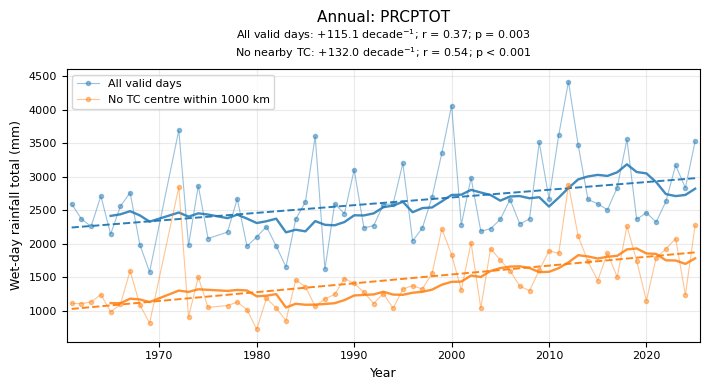

In [34]:
plot_single_index_timeseries(
    data=all_period_indices,
    trend_summary=full_trend_summary,
    index_name="PRCPTOT",
    period_type="Annual",
    period="Annual",
    output_path=DIAGNOSTIC_FIGURE_DIR / "annual_prcptot.png",
    show_running_mean=SHOW_RUNNING_MEAN,
    rolling_window=ROLLING_WINDOW,
    annotate_stats=True,
    figsize=(7.2, 4.0),
)

Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/figures/diagnostic_timeseries/annual_wd.png


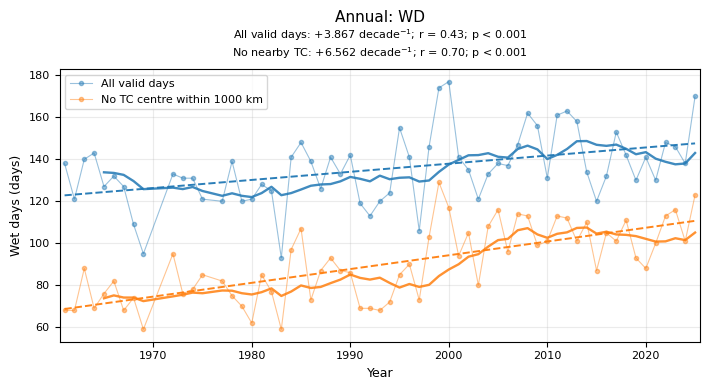

In [35]:
plot_single_index_timeseries(
    data=all_period_indices,
    trend_summary=full_trend_summary,
    index_name="WD",
    period_type="Annual",
    period="Annual",
    output_path=DIAGNOSTIC_FIGURE_DIR / "annual_wd.png",
    show_running_mean=SHOW_RUNNING_MEAN,
    rolling_window=ROLLING_WINDOW,
    annotate_stats=True,
    figsize=(7.2, 4.0),
)

Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/figures/diagnostic_timeseries/annual_wd.png


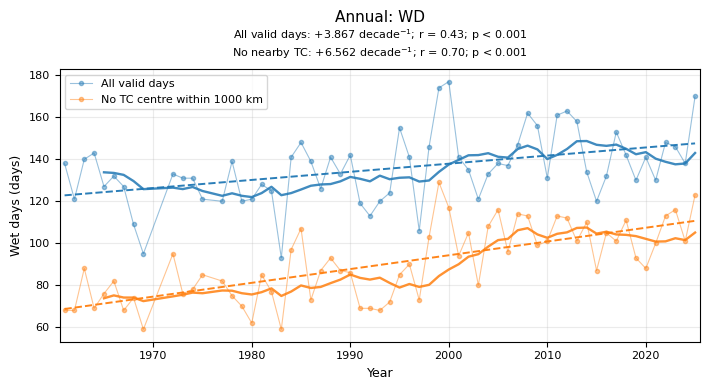

In [36]:
plot_single_index_timeseries(
    data=all_period_indices,
    trend_summary=full_trend_summary,
    index_name="WD",
    period_type="Annual",
    period="Annual",
    output_path=DIAGNOSTIC_FIGURE_DIR / "annual_wd.png",
    show_running_mean=SHOW_RUNNING_MEAN,
    rolling_window=ROLLING_WINDOW,
    annotate_stats=True,
    figsize=(7.2, 4.0),
)

Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/figures/diagnostic_timeseries/annual_r20mm.png


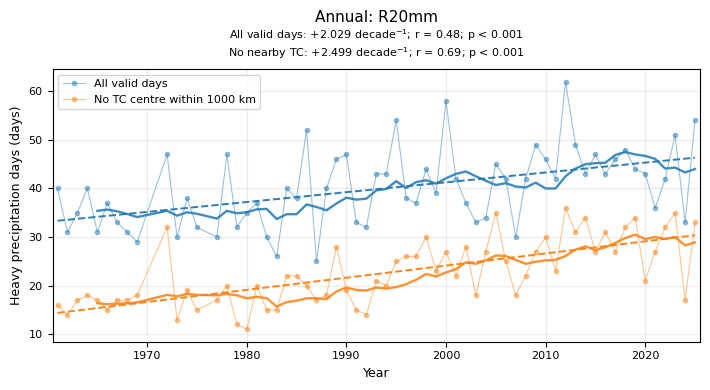

In [37]:
plot_single_index_timeseries(
    data=all_period_indices,
    trend_summary=full_trend_summary,
    index_name="R20mm",
    period_type="Annual",
    period="Annual",
    output_path=DIAGNOSTIC_FIGURE_DIR / "annual_r20mm.png",
    show_running_mean=SHOW_RUNNING_MEAN,
    rolling_window=ROLLING_WINDOW,
    annotate_stats=True,
    figsize=(7.2, 4.0),
)

Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/figures/diagnostic_timeseries/annual_r50mm.png


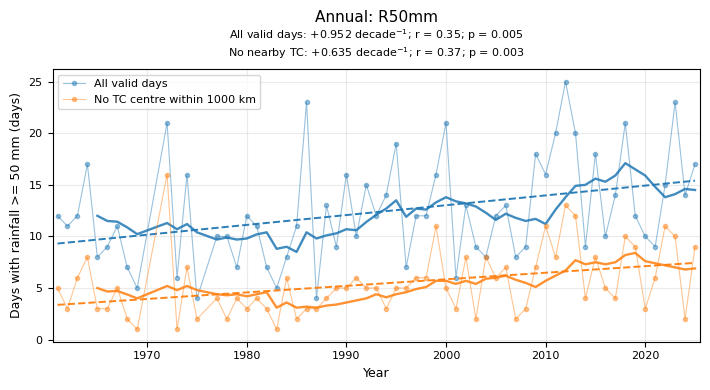

In [38]:
plot_single_index_timeseries(
    data=all_period_indices,
    trend_summary=full_trend_summary,
    index_name="R50mm",
    period_type="Annual",
    period="Annual",
    output_path=DIAGNOSTIC_FIGURE_DIR / "annual_r50mm.png",
    show_running_mean=SHOW_RUNNING_MEAN,
    rolling_window=ROLLING_WINDOW,
    annotate_stats=True,
    figsize=(7.2, 4.0),
)

Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/figures/diagnostic_timeseries/annual_rx1day.png


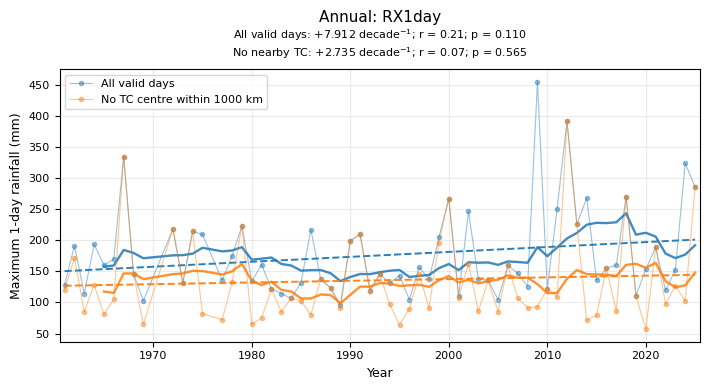

In [39]:
plot_single_index_timeseries(
    data=all_period_indices,
    trend_summary=full_trend_summary,
    index_name="RX1day",
    period_type="Annual",
    period="Annual",
    output_path=DIAGNOSTIC_FIGURE_DIR / "annual_rx1day.png",
    show_running_mean=SHOW_RUNNING_MEAN,
    rolling_window=ROLLING_WINDOW,
    annotate_stats=True,
    figsize=(7.2, 4.0),
)

## Individual May–October rainfall-index plots

This section generates individual diagnostic plots for the May–October season. These plots are intended for inspection and manuscript figure selection.

Each plot shows:

- all-days series;
- TC-proximity-filtered series;
- optional 10-year running mean;
- OLS trend line;
- OLS slope, r-value, and p-value.

In [40]:
print("Wet-season label:", WET_SEASON_LABEL)

display(
    all_period_indices[
        (all_period_indices["period_type"] == "Seasonal")
        & (all_period_indices["period"] == WET_SEASON_LABEL)
    ][["period", "subset", "YEAR", "PRCPTOT", "WD_RATE", "R20mm", "R50mm", "RX1day"]]
    .head()
)

Wet-season label: Wet season (May-Oct)


,period,subset,YEAR,PRCPTOT,WD_RATE,R20mm,R50mm,RX1day
196,Wet season (May-Oct),all_days,1961,2363.8,0.619565,36.0,11.0,128.3
197,Wet season (May-Oct),all_days,1962,2143.7,0.516304,28.0,11.0,191.0
198,Wet season (May-Oct),all_days,1963,2104.3,0.641304,34.0,12.0,114.3
199,Wet season (May-Oct),all_days,1964,2273.3,0.565217,36.0,15.0,193.4
200,Wet season (May-Oct),all_days,1965,1915.3,0.532609,29.0,8.0,159.8


Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/figures/diagnostic_timeseries/may_oct_prcptot.png


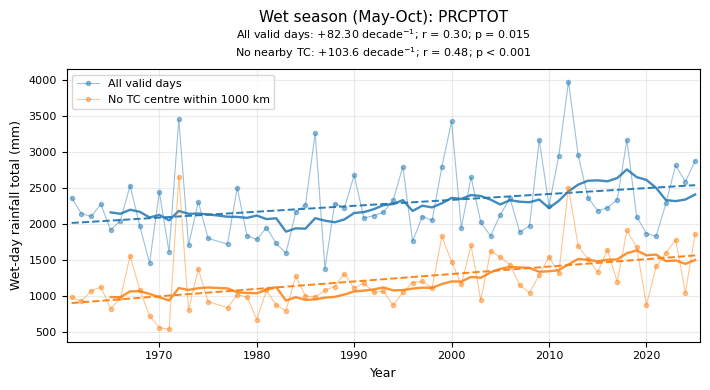

In [41]:
plot_single_index_timeseries(
    data=all_period_indices,
    trend_summary=full_trend_summary,
    index_name="PRCPTOT",
    period_type="Seasonal",
    period=WET_SEASON_LABEL,
    output_path=DIAGNOSTIC_FIGURE_DIR / "may_oct_prcptot.png",
    show_running_mean=SHOW_RUNNING_MEAN,
    rolling_window=ROLLING_WINDOW,
    annotate_stats=True,
    figsize=(7.2, 4.0),
)

Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/figures/diagnostic_timeseries/may_oct_wd_rate.png


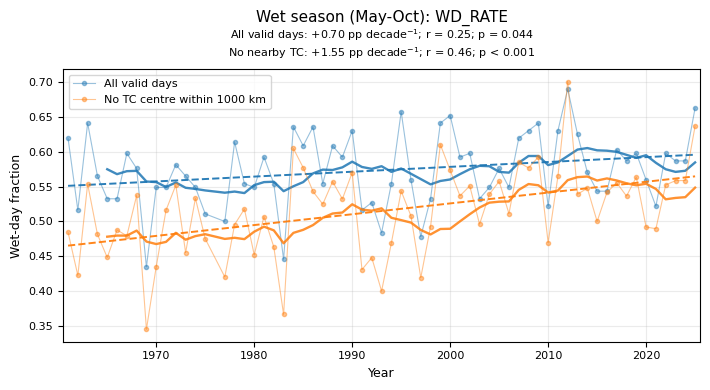

In [42]:
plot_single_index_timeseries(
    data=all_period_indices,
    trend_summary=full_trend_summary,
    index_name="WD_RATE",
    period_type="Seasonal",
    period=WET_SEASON_LABEL,
    output_path=DIAGNOSTIC_FIGURE_DIR / "may_oct_wd_rate.png",
    show_running_mean=SHOW_RUNNING_MEAN,
    rolling_window=ROLLING_WINDOW,
    annotate_stats=True,
    figsize=(7.2, 4.0),
)

Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/figures/diagnostic_timeseries/may_oct_r20mm.png


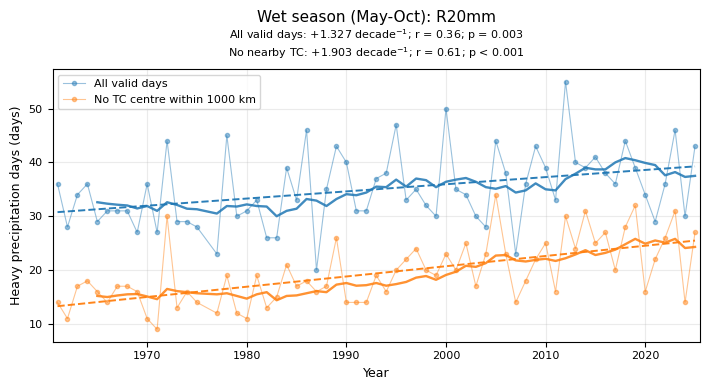

In [43]:
plot_single_index_timeseries(
    data=all_period_indices,
    trend_summary=full_trend_summary,
    index_name="R20mm",
    period_type="Seasonal",
    period=WET_SEASON_LABEL,
    output_path=DIAGNOSTIC_FIGURE_DIR / "may_oct_r20mm.png",
    show_running_mean=SHOW_RUNNING_MEAN,
    rolling_window=ROLLING_WINDOW,
    annotate_stats=True,
    figsize=(7.2, 4.0),
)

Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/figures/diagnostic_timeseries/may_oct_r50mm.png


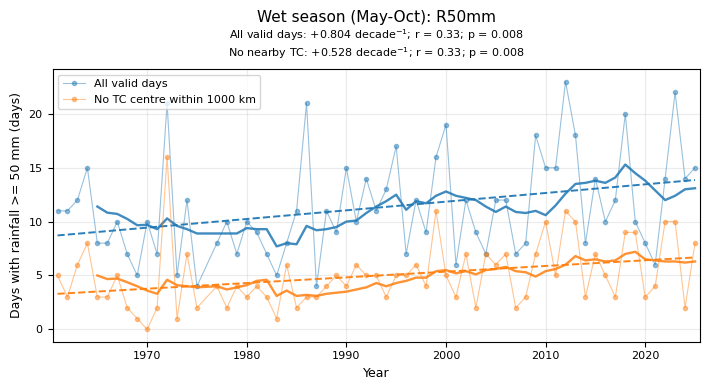

In [44]:
plot_single_index_timeseries(
    data=all_period_indices,
    trend_summary=full_trend_summary,
    index_name="R50mm",
    period_type="Seasonal",
    period=WET_SEASON_LABEL,
    output_path=DIAGNOSTIC_FIGURE_DIR / "may_oct_r50mm.png",
    show_running_mean=SHOW_RUNNING_MEAN,
    rolling_window=ROLLING_WINDOW,
    annotate_stats=True,
    figsize=(7.2, 4.0),
)

Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/figures/diagnostic_timeseries/may_oct_rx1day.png


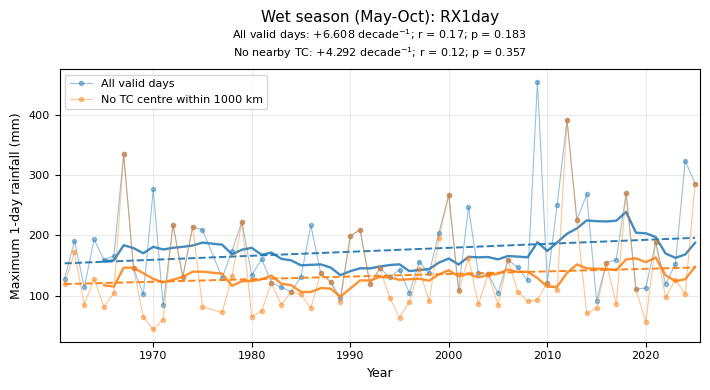

In [45]:
plot_single_index_timeseries(
    data=all_period_indices,
    trend_summary=full_trend_summary,
    index_name="RX1day",
    period_type="Seasonal",
    period=WET_SEASON_LABEL,
    output_path=DIAGNOSTIC_FIGURE_DIR / "may_oct_rx1day.png",
    show_running_mean=SHOW_RUNNING_MEAN,
    rolling_window=ROLLING_WINDOW,
    annotate_stats=True,
    figsize=(7.2, 4.0),
)

Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/figures/diagnostic_timeseries/may_oct_cdd.png


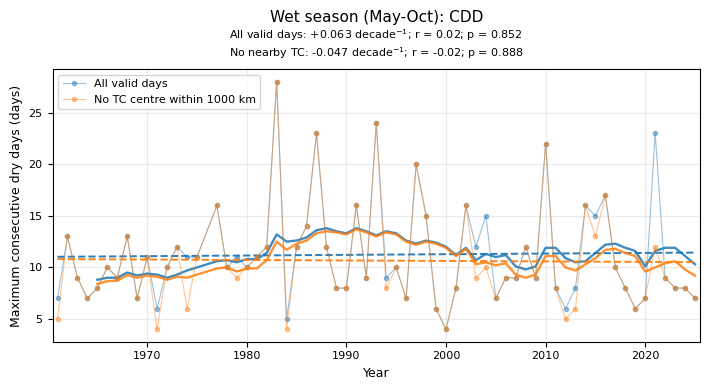

In [46]:
plot_single_index_timeseries(
    data=all_period_indices,
    trend_summary=full_trend_summary,
    index_name="CDD",
    period_type="Seasonal",
    period=WET_SEASON_LABEL,
    output_path=DIAGNOSTIC_FIGURE_DIR / "may_oct_cdd.png",
    show_running_mean=SHOW_RUNNING_MEAN,
    rolling_window=ROLLING_WINDOW,
    annotate_stats=True,
    figsize=(7.2, 4.0),
)

## Individual November–April rainfall-index plots

This section generates individual diagnostic plots for the November–April season. These plots are intended for inspection and manuscript figure selection.

The principal dry-season plots are:

- PRCPTOT;
- WD_RATE;
- R20mm;
- CDD.

Optional dry-spell diagnostic plots are also included for mean dry-spell length and total days within dry spells lasting at least 7 days.

In [47]:
print("Dry-season label:", DRY_SEASON_LABEL)

display(
    all_period_indices[
        (all_period_indices["period_type"] == "Seasonal")
        & (all_period_indices["period"] == DRY_SEASON_LABEL)
    ][
        [
            "period",
            "subset",
            "YEAR",
            "PRCPTOT",
            "WD_RATE",
            "R20mm",
            "CDD",
            "MEAN_DRY_SPELL_LENGTH",
            "TOTAL_DRY_SPELL_DAYS_GE7",
        ]
    ]
    .head()
)

Dry-season label: Dry season (Nov-Apr)


,period,subset,YEAR,PRCPTOT,WD_RATE,R20mm,CDD,MEAN_DRY_SPELL_LENGTH,TOTAL_DRY_SPELL_DAYS_GE7
130,Dry season (Nov-Apr),all_days,1961,NaN,NaN,NaN,NaN,NaN,NaN
131,Dry season (Nov-Apr),all_days,1962,241.9,0.132597,4.0,40.0,9.812500,137.0
132,Dry season (Nov-Apr),all_days,1963,110.7,0.099448,1.0,78.0,20.375000,146.0
133,Dry season (Nov-Apr),all_days,1964,212.4,0.153846,1.0,42.0,9.058824,126.0
134,Dry season (Nov-Apr),all_days,1965,417.9,0.204420,4.0,45.0,7.578947,114.0


Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/figures/diagnostic_timeseries/nov_apr_prcptot.png


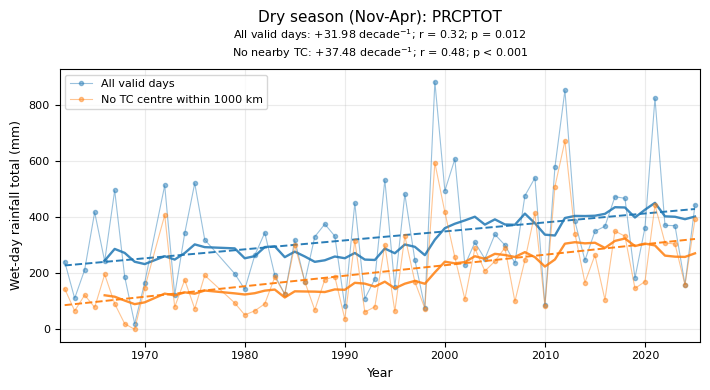

In [48]:
plot_single_index_timeseries(
    data=all_period_indices,
    trend_summary=full_trend_summary,
    index_name="PRCPTOT",
    period_type="Seasonal",
    period=DRY_SEASON_LABEL,
    output_path=DIAGNOSTIC_FIGURE_DIR / "nov_apr_prcptot.png",
    show_running_mean=SHOW_RUNNING_MEAN,
    rolling_window=ROLLING_WINDOW,
    annotate_stats=True,
    figsize=(7.2, 4.0),
)

Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/figures/diagnostic_timeseries/nov_apr_wd_rate.png


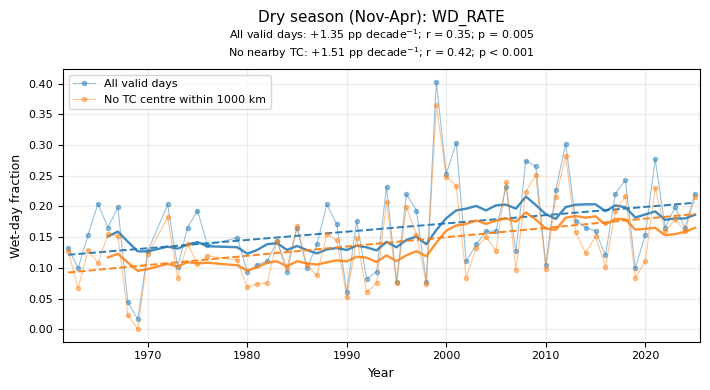

In [49]:
plot_single_index_timeseries(
    data=all_period_indices,
    trend_summary=full_trend_summary,
    index_name="WD_RATE",
    period_type="Seasonal",
    period=DRY_SEASON_LABEL,
    output_path=DIAGNOSTIC_FIGURE_DIR / "nov_apr_wd_rate.png",
    show_running_mean=SHOW_RUNNING_MEAN,
    rolling_window=ROLLING_WINDOW,
    annotate_stats=True,
    figsize=(7.2, 4.0),
)

Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/figures/diagnostic_timeseries/nov_apr_r20mm.png


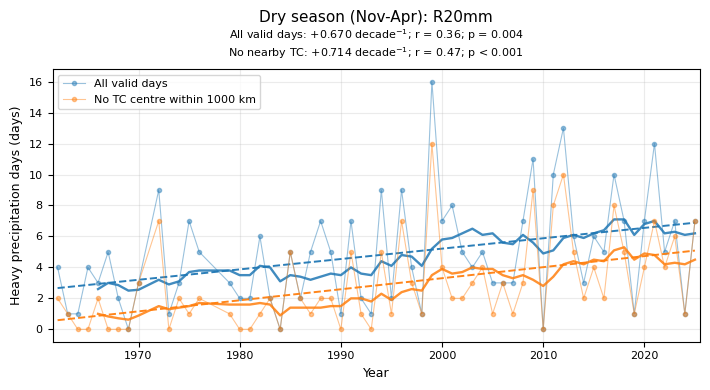

In [50]:
plot_single_index_timeseries(
    data=all_period_indices,
    trend_summary=full_trend_summary,
    index_name="R20mm",
    period_type="Seasonal",
    period=DRY_SEASON_LABEL,
    output_path=DIAGNOSTIC_FIGURE_DIR / "nov_apr_r20mm.png",
    show_running_mean=SHOW_RUNNING_MEAN,
    rolling_window=ROLLING_WINDOW,
    annotate_stats=True,
    figsize=(7.2, 4.0),
)

Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/figures/diagnostic_timeseries/nov_apr_cdd.png


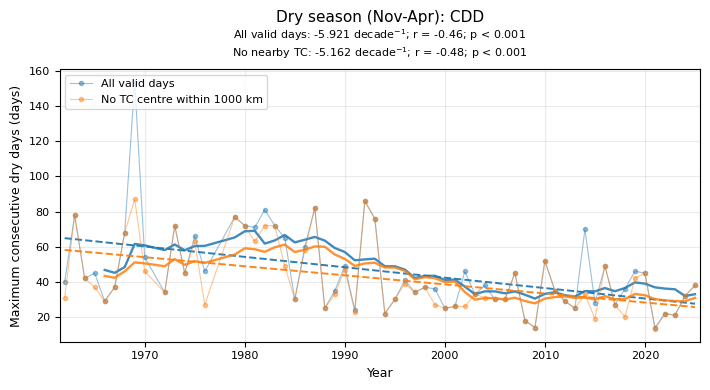

In [51]:
plot_single_index_timeseries(
    data=all_period_indices,
    trend_summary=full_trend_summary,
    index_name="CDD",
    period_type="Seasonal",
    period=DRY_SEASON_LABEL,
    output_path=DIAGNOSTIC_FIGURE_DIR / "nov_apr_cdd.png",
    show_running_mean=SHOW_RUNNING_MEAN,
    rolling_window=ROLLING_WINDOW,
    annotate_stats=True,
    figsize=(7.2, 4.0),
)

Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/figures/diagnostic_timeseries/nov_apr_mean_dry_spell_length.png


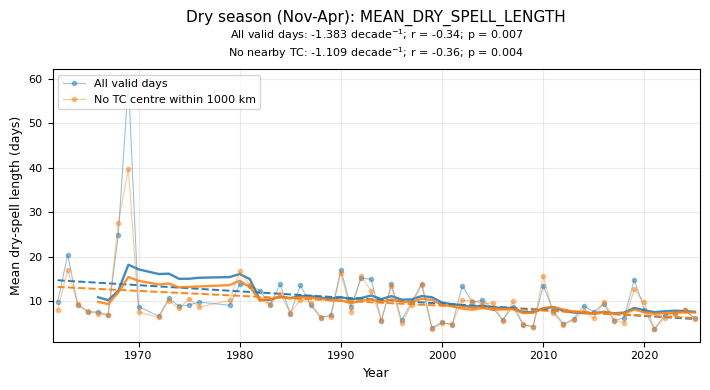

In [52]:
plot_single_index_timeseries(
    data=all_period_indices,
    trend_summary=full_trend_summary,
    index_name="MEAN_DRY_SPELL_LENGTH",
    period_type="Seasonal",
    period=DRY_SEASON_LABEL,
    output_path=DIAGNOSTIC_FIGURE_DIR / "nov_apr_mean_dry_spell_length.png",
    show_running_mean=SHOW_RUNNING_MEAN,
    rolling_window=ROLLING_WINDOW,
    annotate_stats=True,
    figsize=(7.2, 4.0),
)

Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/figures/diagnostic_timeseries/nov_apr_total_dry_spell_days_ge7.png


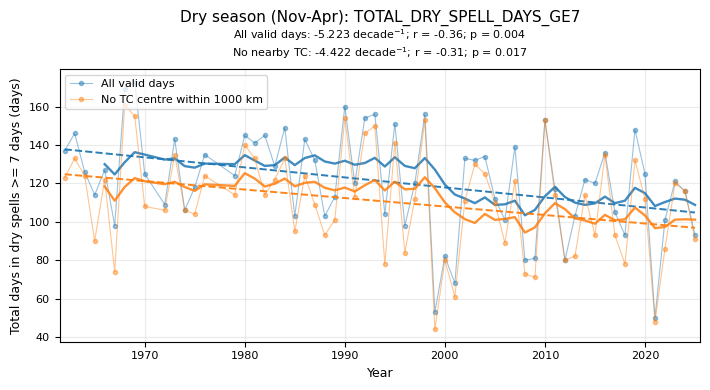

In [53]:
plot_single_index_timeseries(
    data=all_period_indices,
    trend_summary=full_trend_summary,
    index_name="TOTAL_DRY_SPELL_DAYS_GE7",
    period_type="Seasonal",
    period=DRY_SEASON_LABEL,
    output_path=DIAGNOSTIC_FIGURE_DIR / "nov_apr_total_dry_spell_days_ge7.png",
    show_running_mean=SHOW_RUNNING_MEAN,
    rolling_window=ROLLING_WINDOW,
    annotate_stats=True,
    figsize=(7.2, 4.0),
)

## Supplementary Figure S1. Data completeness

This section summarizes daily rainfall data completeness by year and by month.

Completeness is calculated using the cleaned rainfall series. A day is considered valid if cleaned rainfall is not missing. Trace rainfall is treated as valid because it is retained and converted to 0.0 mm.

The annual and monthly completeness summaries are used to verify which years and months meet the minimum valid-fraction threshold used in the rainfall-index calculations.

In [54]:
# -----------------------------
# Annual completeness
# -----------------------------
annual_completeness = (
    analysis_df
    .groupby("YEAR")
    .agg(
        valid_days=("RAINFALL", "count"),
        wet_days=("RAINFALL", lambda x: (x >= WET_DAY_THRESHOLD).sum()),
        tc1000_days=(TC_FILTER_COL, "sum"),
    )
    .reset_index()
)

annual_completeness["expected_days"] = annual_completeness["YEAR"].apply(
    expected_days_in_year
)

annual_completeness["missing_days"] = (
    annual_completeness["expected_days"] - annual_completeness["valid_days"]
)

annual_completeness["valid_fraction"] = (
    annual_completeness["valid_days"] / annual_completeness["expected_days"]
)

annual_completeness["is_valid_year"] = (
    annual_completeness["valid_fraction"] >= MIN_VALID_FRACTION
)


# -----------------------------
# Monthly completeness
# -----------------------------
monthly_completeness = (
    analysis_df
    .groupby(["YEAR", "MONTH"])
    .agg(
        valid_days=("RAINFALL", "count"),
        wet_days=("RAINFALL", lambda x: (x >= WET_DAY_THRESHOLD).sum()),
        tc1000_days=(TC_FILTER_COL, "sum"),
    )
    .reset_index()
)

monthly_completeness["expected_days"] = monthly_completeness.apply(
    lambda row: expected_days_in_month(row["YEAR"], row["MONTH"]),
    axis=1
)

monthly_completeness["missing_days"] = (
    monthly_completeness["expected_days"] - monthly_completeness["valid_days"]
)

monthly_completeness["valid_fraction"] = (
    monthly_completeness["valid_days"] / monthly_completeness["expected_days"]
)

monthly_completeness["is_valid_month"] = (
    monthly_completeness["valid_fraction"] >= MIN_VALID_FRACTION
)

display(annual_completeness.head())
display(monthly_completeness.head())

,YEAR,valid_days,wet_days,tc1000_days,expected_days,missing_days,valid_fraction,is_valid_year
0,1961,361,138,101,365,4,0.989041,True
1,1962,365,121,85,365,0,1.000000,True
2,1963,365,140,67,365,0,1.000000,True
3,1964,366,143,110,366,0,1.000000,True
4,1965,365,127,93,365,0,1.000000,True


,YEAR,MONTH,valid_days,wet_days,tc1000_days,expected_days,missing_days,valid_fraction,is_valid_month
0,1961,1,27,0,0,31,4,0.870968,False
1,1961,2,28,3,0,28,0,1.000000,True
2,1961,3,31,7,0,31,0,1.000000,True
3,1961,4,30,2,0,30,0,1.000000,True
4,1961,5,31,12,11,31,0,1.000000,True


In [55]:
ANNUAL_COMPLETENESS_PATH = TABLE_DIR / "annual_data_completeness.csv"
MONTHLY_COMPLETENESS_PATH = TABLE_DIR / "monthly_data_completeness.csv"

annual_completeness.to_csv(ANNUAL_COMPLETENESS_PATH, index=False)
monthly_completeness.to_csv(MONTHLY_COMPLETENESS_PATH, index=False)

print("Saved completeness tables:")
print(f"- {ANNUAL_COMPLETENESS_PATH}")
print(f"- {MONTHLY_COMPLETENESS_PATH}")

Saved completeness tables:
- /home/jupyter-bbr/source/science-garden-rainfall-trends/output/tables/annual_data_completeness.csv
- /home/jupyter-bbr/source/science-garden-rainfall-trends/output/tables/monthly_data_completeness.csv


In [56]:
monthly_completeness_matrix = (
    monthly_completeness
    .pivot(index="YEAR", columns="MONTH", values="valid_fraction")
    .sort_index()
)

monthly_completeness_matrix = monthly_completeness_matrix.reindex(
    columns=range(1, 13)
)

display(monthly_completeness_matrix.head())

MONTH,1,2,3,4,5,6,7,8,9,10,11,12
YEAR,,,,,,,,,,,,
1961,0.870968,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1962,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1963,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1964,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1965,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


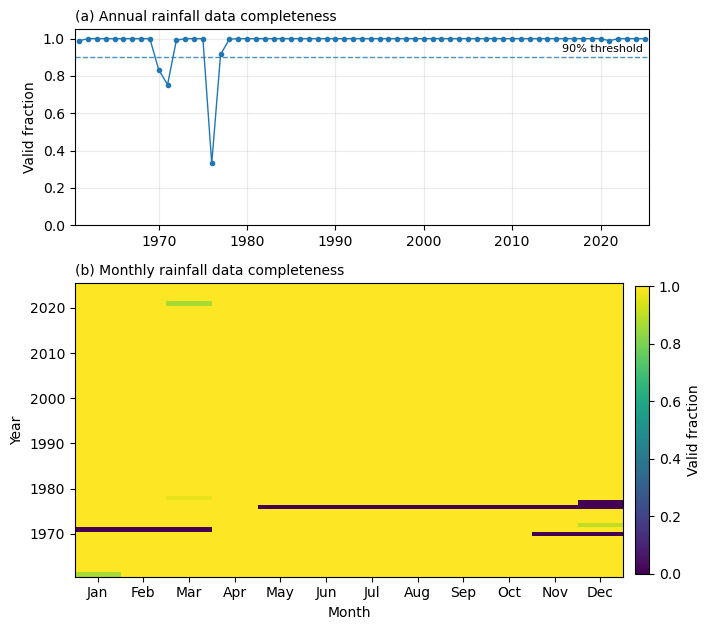

Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/figures/supplementary/supplementary_figure_s1_data_completeness.png


In [57]:
SUPP_FIGURE_S1_PATH = SUPP_FIGURE_DIR / "supplementary_figure_s1_data_completeness.png"

fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(7.2, 6.4),
    gridspec_kw={"height_ratios": [1.0, 1.5]}
)

# -----------------------------
# Panel a: Annual valid fraction
# -----------------------------
ax = axes[0]

ax.plot(
    annual_completeness["YEAR"],
    annual_completeness["valid_fraction"],
    marker="o",
    markersize=3,
    linewidth=1.0,
)

ax.axhline(
    MIN_VALID_FRACTION,
    linestyle="--",
    linewidth=1.0,
    alpha=0.8,
)

ax.set_title("(a) Annual rainfall data completeness", loc="left", fontsize=10)
ax.set_ylabel("Valid fraction")
ax.set_ylim(0, 1.05)
ax.set_xlim(
    annual_completeness["YEAR"].min() - 0.5,
    annual_completeness["YEAR"].max() + 0.5,
)
ax.set_xticks(
    np.arange(
        int(np.ceil(annual_completeness["YEAR"].min() / 10) * 10),
        int(np.floor(annual_completeness["YEAR"].max() / 10) * 10) + 1,
        10,
    )
)
ax.grid(True, alpha=0.25)

ax.text(
    0.99,
    MIN_VALID_FRACTION + 0.02,
    f"{MIN_VALID_FRACTION:.0%} threshold",
    transform=ax.get_yaxis_transform(),
    ha="right",
    va="bottom",
    fontsize=8,
)

# -----------------------------
# Panel b: Monthly completeness heatmap
# -----------------------------
ax = axes[1]

matrix_values = monthly_completeness_matrix.to_numpy()

im = ax.imshow(
    matrix_values,
    aspect="auto",
    vmin=0,
    vmax=1,
    origin="lower",
)

years = monthly_completeness_matrix.index.to_numpy()

ax.set_title("(b) Monthly rainfall data completeness", loc="left", fontsize=10)
ax.set_xlabel("Month")
ax.set_ylabel("Year")

ax.set_xticks(np.arange(12))
ax.set_xticklabels(MONTH_LABELS)

# Use decadal year labels
decade_years = np.arange(
    int(np.ceil(years.min() / 10) * 10),
    int(np.floor(years.max() / 10) * 10) + 1,
    10,
)

year_tick_positions = [
    np.where(years == year)[0][0]
    for year in decade_years
    if year in years
]

year_tick_labels = [
    str(year)
    for year in decade_years
    if year in years
]

ax.set_yticks(year_tick_positions)
ax.set_yticklabels(year_tick_labels)

cbar = fig.colorbar(im, ax=ax, orientation="vertical", fraction=0.025, pad=0.02)
cbar.set_label("Valid fraction")

plt.tight_layout()
plt.savefig(SUPP_FIGURE_S1_PATH, dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()

print(f"Saved: {SUPP_FIGURE_S1_PATH}")

In [58]:
# COMPOSITE_INDICES = [
#     "PRCPTOT",
#     "WD_RATE",
#     "R20mm",
#     "R50mm",
#     "RX1day",
#     "CDD",
# ]
COMPOSITE_INDICES = [
    "PRCPTOT",
    "WD",
    "R20mm",
    "R50mm",
    "RX1day",
    "CDD",
]

COMPOSITE_FIGURE_02_PATH = FIGURE_DIR / "figure_02_annual_composite.png"
COMPOSITE_FIGURE_03_PATH = FIGURE_DIR / "figure_03_nov_apr_composite.png"
COMPOSITE_FIGURE_04_PATH = FIGURE_DIR / "figure_04_may_oct_composite.png"

In [59]:
def format_p_compact(p):
    if pd.isna(p):
        return "p=NA"
    if p < 0.001:
        return "p<0.001"
    return f"p={p:.3f}"


def format_slope_compact(slope_per_decade, index_name):
    """
    Format slope for compact panel annotation.
    
    Fraction indices are converted to percentage points per decade.
    """
    if pd.isna(slope_per_decade):
        return "NA"
    
    unit = INDEX_METADATA.get(index_name, {}).get("unit", "")
    
    if unit == "fraction":
        return f"{slope_per_decade * 100:+.2f} pp/dec"
    
    if abs(slope_per_decade) >= 100:
        return f"{slope_per_decade:+.1f}/dec"
    elif abs(slope_per_decade) >= 10:
        return f"{slope_per_decade:+.2f}/dec"
    else:
        return f"{slope_per_decade:+.3f}/dec"


def get_panel_annotation(
    trend_summary,
    period_type,
    period,
    index_name,
    subset,
):
    row = trend_summary[
        (trend_summary["period_type"] == period_type)
        & (trend_summary["period"] == period)
        & (trend_summary["subset"] == subset)
        & (trend_summary["index"] == index_name)
    ]
    
    if len(row) == 0:
        return None
    
    row = row.iloc[0]
    
    subset_short = {
        "all_days": "All valid days",
        "non_tc_1000km": "No nearby TC",
    }.get(subset, subset)
    
    slope_text = format_slope_compact(row["ols_slope_per_decade"], index_name)
    p_text = format_p_compact(row["ols_p_value"])
    
    return f"{subset_short}: {slope_text}, {p_text}"

In [191]:
def plot_composite_panel(
    ax,
    data,
    trend_summary,
    index_name,
    period_type,
    period,
    subsets=("all_days", "non_tc_1000km"),
    annotate_stats=True,
):
    """
    Plot one index panel for a composite manuscript-style figure.

    Shows raw values and OLS trend lines.
    Does not show running means by default to reduce clutter.
    """

    # --------------------------------------------------------
    # Font sizes
    # --------------------------------------------------------

    TITLE_FS = 12
    YLABEL_FS = 9.5
    TICK_FS = 9
    ANNOTATION_FS = 9.5

    # ============================================================
    # Manual y-axis limits for composite figures
    # ============================================================
    
    YLIM_LOOKUP = {
        # --------------------------------------------------------
        # Annual
        # --------------------------------------------------------
        ("Annual", "PRCPTOT"): (0, 5000),
        ("Annual", "WD"): (0, 300),
        ("Annual", "WD_RATE"): (20, 50),
        ("Annual", "SDII"): (10, 25),
        ("Annual", "R20mm"): (0, 80),
        ("Annual", "R50mm"): (0, 30),
        ("Annual", "R100mm"): (0, 12),
        ("Annual", "RX1day"): (0, 500),
        ("Annual", "RX5day"): (100, 800),
        ("Annual", "CDD"): (0, 120),
    
        # --------------------------------------------------------
        # Dry season (Nov-Apr)
        # --------------------------------------------------------
        ("Dry season (Nov-Apr)", "PRCPTOT"): (0, 1200),
        ("Dry season (Nov-Apr)", "WD"): (0, 70),
        ("Dry season (Nov-Apr)", "WD_RATE"): (0, 40),
        ("Dry season (Nov-Apr)", "SDII"): (0, 30),
        ("Dry season (Nov-Apr)", "R20mm"): (0, 25),
        ("Dry season (Nov-Apr)", "R50mm"): (0, 10),
        ("Dry season (Nov-Apr)", "R100mm"): (0, 5),
        ("Dry season (Nov-Apr)", "RX1day"): (0, 300),
        ("Dry season (Nov-Apr)", "RX5day"): (0, 500),
        ("Dry season (Nov-Apr)", "CDD"): (0, 100),
    
        # --------------------------------------------------------
        # Wet season (May-Oct)
        # --------------------------------------------------------
        ("Wet season (May-Oct)", "PRCPTOT"): (0, 5000),
        ("Wet season (May-Oct)", "WD"): (0, 200),
        ("Wet season (May-Oct)", "WD_RATE"): (30, 80),
        ("Wet season (May-Oct)", "SDII"): (10, 30),
        ("Wet season (May-Oct)", "R20mm"): (0, 70),
        ("Wet season (May-Oct)", "R50mm"): (0, 30),
        ("Wet season (May-Oct)", "R100mm"): (0, 12),
        ("Wet season (May-Oct)", "RX1day"): (0, 500),
        ("Wet season (May-Oct)", "RX5day"): (100, 800),
        ("Wet season (May-Oct)", "CDD"): (0, 60),
    }
    # --------------------------------------------------------
    # Y-axis labels
    # --------------------------------------------------------

    YLABEL_LOOKUP = {
        "PRCPTOT": "Rainfall (mm)",
        "WD": "Wet days",
        "WD_RATE": "Wet days (%)",
        "SDII": "Intensity (mm day$^{-1}$)",
        "R20mm": "Days",
        "R50mm": "Days",
        "R100mm": "Days",
        "RX1day": "Rainfall (mm)",
        "RX5day": "Rainfall (mm)",
        "CDD": "Dry days",
    }

    all_valid_years = []
    annotation_lines = []

    # --------------------------------------------------------
    # Plot each subset
    # --------------------------------------------------------

    for subset in subsets:

        g = data[
            (data["period_type"] == period_type)
            & (data["period"] == period)
            & (data["subset"] == subset)
        ].sort_values("YEAR").copy()

        if g.empty or index_name not in g.columns:
            continue

        valid_g = g[
            g[index_name].notna()
        ].copy()

        if valid_g.empty:
            continue

        all_valid_years.extend(
            valid_g["YEAR"].tolist()
        )

        # ----------------------------------------------------
        # Raw series
        # ----------------------------------------------------

        line = ax.plot(
            valid_g["YEAR"],
            valid_g[index_name],
            marker="o",
            markersize=2.6,
            linewidth=0.8,
            alpha=0.45,
            label=subset_label(subset),
        )[0]

        line_color = line.get_color()

        # ----------------------------------------------------
        # OLS trend line
        # ----------------------------------------------------

        trend_row = trend_summary[
            (trend_summary["period_type"] == period_type)
            & (trend_summary["period"] == period)
            & (trend_summary["subset"] == subset)
            & (trend_summary["index"] == index_name)
        ]

        if len(trend_row) > 0:

            trend_row = trend_row.iloc[0]

            if (
                pd.notna(
                    trend_row["ols_slope_per_year"]
                )
                and pd.notna(
                    trend_row["ols_intercept"]
                )
            ):

                x_trend = np.array(
                    [
                        valid_g["YEAR"].min(),
                        valid_g["YEAR"].max(),
                    ]
                )

                y_trend = (
                    trend_row["ols_intercept"]
                    + trend_row["ols_slope_per_year"]
                    * x_trend
                )

                ax.plot(
                    x_trend,
                    y_trend,
                    linewidth=1.4,
                    linestyle="--",
                    color=line_color,
                    alpha=0.95,
                )

        # ----------------------------------------------------
        # Trend annotation
        # ----------------------------------------------------

        if annotate_stats:

            annotation = get_panel_annotation(
                trend_summary=trend_summary,
                period_type=period_type,
                period=period,
                index_name=index_name,
                subset=subset,
            )

            if annotation is not None:
                annotation_lines.append(
                    annotation
                )

    # --------------------------------------------------------
    # Panel title
    # --------------------------------------------------------

    ax.set_title(
        index_name,
        fontsize=TITLE_FS,
        fontweight="bold",
        loc="center",
        pad=5,
    )

    # --------------------------------------------------------
    # Y-axis label
    # --------------------------------------------------------

    ax.set_ylabel(
        YLABEL_LOOKUP.get(
            index_name,
            index_name,
        ),
        fontsize=YLABEL_FS,
        labelpad=4,
    )

    # --------------------------------------------------------
    # X-axis limits and ticks
    # --------------------------------------------------------

    if len(all_valid_years) > 0:

        year_min = int(
            np.min(all_valid_years)
        )

        year_max = int(
            np.max(all_valid_years)
        )

        xlim_min = int(
            np.floor(
                year_min / 10
            )
            * 10
        )

        xlim_max = int(
            np.ceil(
                year_max / 5
            )
            * 5
        )

        ax.set_xlim(
            xlim_min,
            xlim_max,
        )

        decade_ticks = np.arange(
            xlim_min,
            xlim_max + 1,
            10,
        )

        decade_ticks = decade_ticks[
            decade_ticks <= year_max
        ]

        ax.set_xticks(
            decade_ticks
        )

    # --------------------------------------------------------
    # Annotation inside panel
    # --------------------------------------------------------

    if (
        annotate_stats
        and len(annotation_lines) > 0
    ):

        ax.text(
            0.02,
            0.96,
            "\n".join(annotation_lines),
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=ANNOTATION_FS,
            linespacing=1.25,
            bbox={
                "boxstyle": "round,pad=0.25",
                "facecolor": "white",
                "edgecolor": "none",
                "alpha": 0.78,
            },
        )

    # --------------------------------------------------------
    # Manual y-axis limits
    # --------------------------------------------------------

    ylim = YLIM_LOOKUP.get(
        (period, index_name)
    )

    if ylim is not None:
        ax.set_ylim(*ylim)

    # --------------------------------------------------------
    # Styling
    # --------------------------------------------------------

    ax.grid(
        True,
        alpha=0.25,
    )

    ax.tick_params(
        axis="both",
        labelsize=TICK_FS,
    )

In [113]:
def make_composite_timeseries_figure(
    data,
    trend_summary,
    indices,
    period_type,
    period,
    output_path,
    figure_title,
    ncols=2,
    panel_width=3.6,
    panel_height=2.45,
    annotate_stats=True,
):
    """
    Create a manuscript-style multi-panel figure.
    
    Recommended for drafting:
    - 6 indices;
    - 2 columns x 3 rows;
    - raw series + OLS trends;
    - compact slope and p-value annotations.
    """
    n_panels = len(indices)
    nrows = int(np.ceil(n_panels / ncols))
    
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(panel_width * ncols, panel_height * nrows),
        sharex=False,
    )
    
    axes = np.array(axes).reshape(-1)
    panel_labels = list("abcdefghijklmnopqrstuvwxyz")
    
    LEGEND_FS = 11
    
    for i, index_name in enumerate(indices):
        ax = axes[i]
        
        plot_composite_panel(
            ax=ax,
            data=data,
            trend_summary=trend_summary,
            index_name=index_name,
            period_type=period_type,
            period=period,
            annotate_stats=annotate_stats,
        )
        # Prevent the first and last years from being clipped
        x_min, x_max = ax.get_xlim()
        ax.set_xlim(x_min - 1, x_max + 1)        
        # Panel label, top right
        ax.text(
            0.98,
            0.98,
            f"({panel_labels[i]})",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=9,
            fontweight="bold",
            bbox={
                "boxstyle": "round,pad=0.15",
                "facecolor": "white",
                "edgecolor": "none",
                "alpha": 0.75,
            },
        )
    
    # Hide unused axes
    for j in range(n_panels, len(axes)):
        axes[j].set_visible(False)
    
    # X-labels only on bottom row to reduce clutter
    for i, ax in enumerate(axes[:n_panels]):
        row = i // ncols
        if row == nrows - 1:
            ax.set_xlabel("Year", fontsize=10)
        else:
            ax.set_xlabel("")
    
    # Common legend
    handles, labels = axes[0].get_legend_handles_labels()
    
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=2,
        frameon=False,
        fontsize=LEGEND_FS,
    )
    
    # fig.suptitle(figure_title, fontsize=12, y=0.995)
    
    # plt.tight_layout(rect=[0, 0.045, 1, 0.965])
    
    # fig.suptitle(
    #     figure_title,
    #     fontsize=12,
    # )
    
    # plt.tight_layout(
    #     rect=[0, 0.045, 1, 0.97]
    # )    

    fig.suptitle(
        figure_title,
        fontsize=16,
        y=0.985,
    )
    
    plt.tight_layout(
        rect=[0, 0.045, 1, 0.985]
    )
    fig.subplots_adjust(
        hspace=0.35,
    )
    plt.savefig(output_path, dpi=FIGURE_DPI, bbox_inches="tight")
    plt.show()
    
    print(f"Saved: {output_path}")

In [62]:
COMPOSITE_INDICES

['PRCPTOT', 'WD', 'R20mm', 'R50mm', 'RX1day', 'CDD']

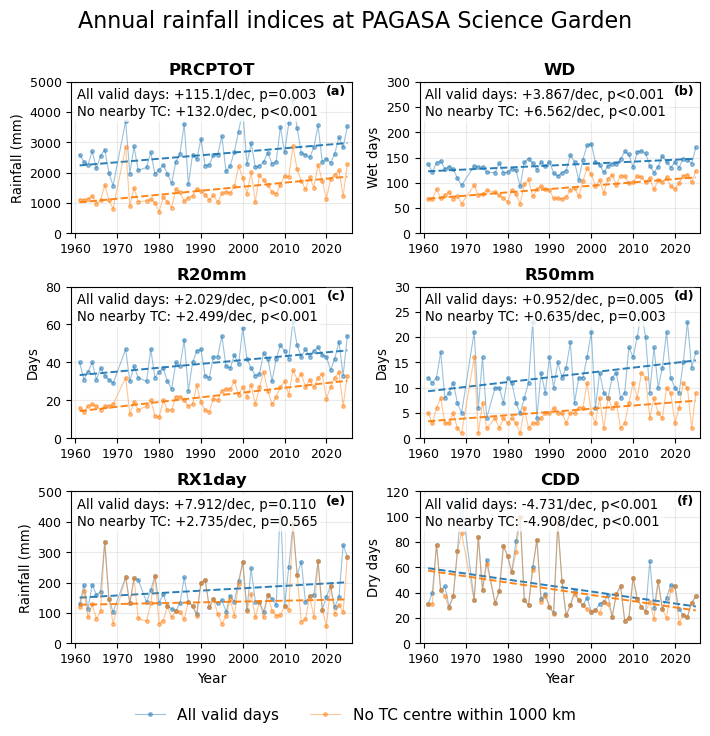

Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/figures/figure_02_annual_composite.png


In [185]:
make_composite_timeseries_figure(
    data=all_period_indices,
    trend_summary=full_trend_summary,
    indices=COMPOSITE_INDICES,
    period_type="Annual",
    period="Annual",
    output_path=COMPOSITE_FIGURE_02_PATH,
    figure_title="Annual rainfall indices at PAGASA Science Garden",
    ncols=2,
    panel_width=3.6,
    panel_height=2.45,
    annotate_stats=True,
)

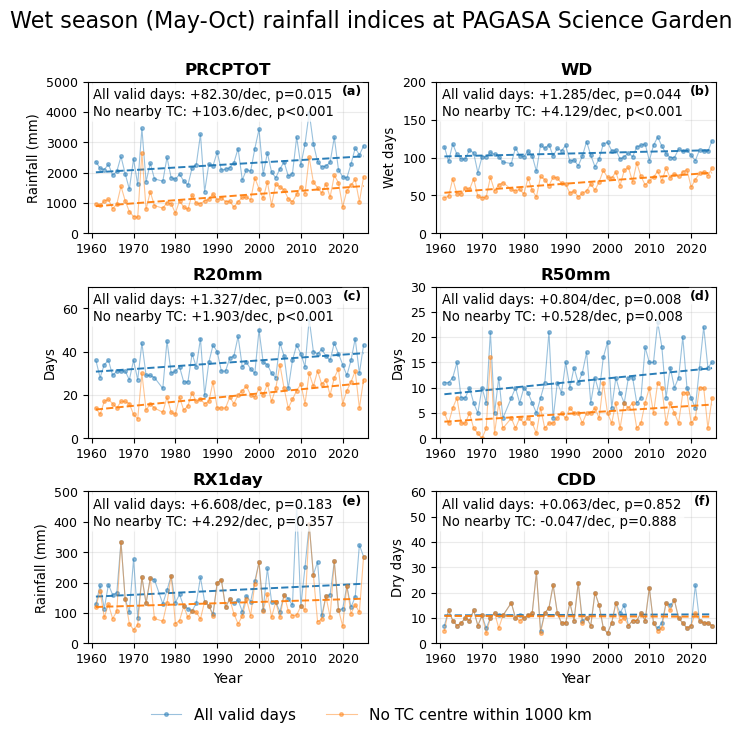

Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/figures/figure_04_may_oct_composite.png


In [192]:
make_composite_timeseries_figure(
    data=all_period_indices,
    trend_summary=full_trend_summary,
    indices=COMPOSITE_INDICES,
    period_type="Seasonal",
    period=WET_SEASON_LABEL,
    output_path=COMPOSITE_FIGURE_04_PATH,
    figure_title=f"{WET_SEASON_LABEL} rainfall indices at PAGASA Science Garden",
    ncols=2,
    panel_width=3.6,
    panel_height=2.45,
    annotate_stats=True,
)

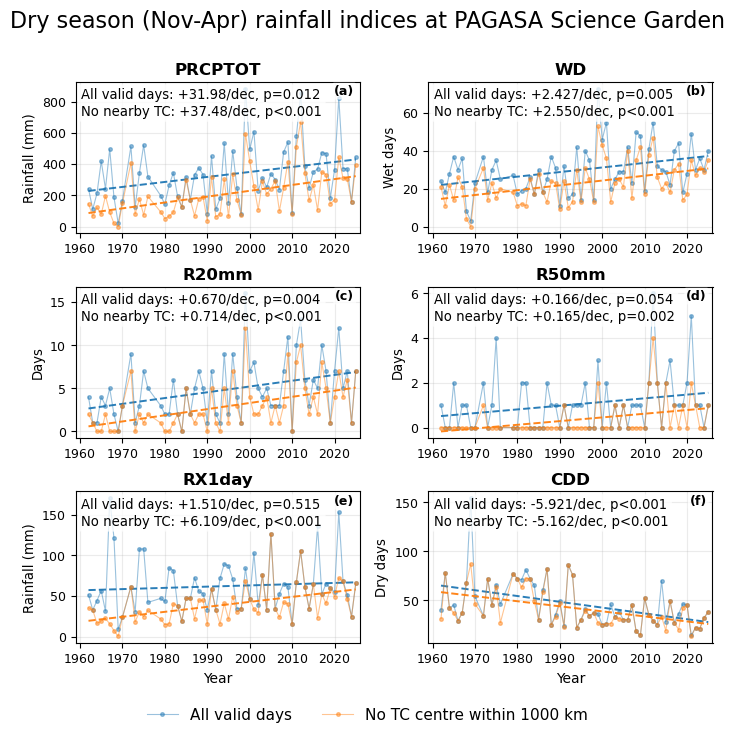

Saved: /home/jupyter-bbr/source/science-garden-rainfall-trends/output/figures/figure_03_nov_apr_composite.png


In [116]:
make_composite_timeseries_figure(
    data=all_period_indices,
    trend_summary=full_trend_summary,
    indices=COMPOSITE_INDICES,
    period_type="Seasonal",
    period=DRY_SEASON_LABEL,
    output_path=COMPOSITE_FIGURE_03_PATH,
    figure_title=f"{DRY_SEASON_LABEL} rainfall indices at PAGASA Science Garden",
    ncols=2,
    panel_width=3.6,
    panel_height=2.45,
    annotate_stats=True,
)

In [66]:
# ------------------------------------------------------------
# Station-specific support for R50mm threshold
# Science Garden, 1991-2020 reference period
# ------------------------------------------------------------

R50_THRESHOLD = 50.0
WET_DAY_THRESHOLD = 1.0
CLIM_START = 1991
CLIM_END = 2020
MIN_VALID_FRACTION = 0.90

# Change this if your cleaned Science Garden dataframe has a different name
sg_daily = analysis_df.copy()

# Ensure date fields exist
sg_daily["DATE"] = pd.to_datetime(sg_daily["DATE"])
sg_daily["YEAR"] = sg_daily["DATE"].dt.year
sg_daily["MONTH"] = sg_daily["DATE"].dt.month
sg_daily["DAY"] = sg_daily["DATE"].dt.day

# Use all-days observed rainfall for threshold justification
rain_col = "RAINFALL"

# ------------------------------------------------------------
# 1. Percentile rank of 50 mm among wet days, 1991-2020
# ------------------------------------------------------------

ref_daily = sg_daily[
    (sg_daily["DATE"] >= pd.Timestamp(f"{CLIM_START}-01-01"))
    & (sg_daily["DATE"] <= pd.Timestamp(f"{CLIM_END}-12-31"))
].copy()

ref_wet_day_rain = ref_daily.loc[
    ref_daily[rain_col].notna()
    & (ref_daily[rain_col] >= WET_DAY_THRESHOLD),
    rain_col,
]

r50_distribution_summary = pd.DataFrame([
    {
        "reference_period": f"{CLIM_START}-{CLIM_END}",
        "wet_day_threshold_mm": WET_DAY_THRESHOLD,
        "r50_threshold_mm": R50_THRESHOLD,
        "n_wet_days": len(ref_wet_day_rain),
        "percentile_rank_lt_50mm": (ref_wet_day_rain < R50_THRESHOLD).mean() * 100,
        "percentile_rank_le_50mm": (ref_wet_day_rain <= R50_THRESHOLD).mean() * 100,
        "wet_day_exceedance_fraction_ge_50mm": (ref_wet_day_rain >= R50_THRESHOLD).mean(),
        "wet_day_exceedance_percent_ge_50mm": (ref_wet_day_rain >= R50_THRESHOLD).mean() * 100,
    }
])

display(r50_distribution_summary)

,reference_period,wet_day_threshold_mm,r50_threshold_mm,n_wet_days,percentile_rank_lt_50mm,percentile_rank_le_50mm,wet_day_exceedance_fraction_ge_50mm,wet_day_exceedance_percent_ge_50mm
0,1991-2020,1.0,50.0,4210,90.285036,90.308789,0.09715,9.714964


In [67]:
# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def count_expected_days(start_date, end_date):
    return len(pd.date_range(start_date, end_date, freq="D"))


def summarize_r50_period(period_df, expected_days, label_dict):
    valid_days = period_df[rain_col].notna().sum()
    valid_fraction = valid_days / expected_days if expected_days > 0 else np.nan
    
    r50_days = (
        period_df.loc[period_df[rain_col].notna(), rain_col] >= R50_THRESHOLD
    ).sum()
    
    return {
        **label_dict,
        "expected_days": expected_days,
        "valid_days": valid_days,
        "valid_fraction": valid_fraction,
        "is_valid": valid_fraction >= MIN_VALID_FRACTION,
        "r50_days": r50_days if valid_fraction >= MIN_VALID_FRACTION else np.nan,
    }


# ------------------------------------------------------------
# Annual R50mm counts
# ------------------------------------------------------------

annual_rows = []

for year in range(CLIM_START, CLIM_END + 1):
    start_date = pd.Timestamp(f"{year}-01-01")
    end_date = pd.Timestamp(f"{year}-12-31")
    
    period_df = sg_daily[
        (sg_daily["DATE"] >= start_date)
        & (sg_daily["DATE"] <= end_date)
    ].copy()
    
    annual_rows.append(
        summarize_r50_period(
            period_df=period_df,
            expected_days=count_expected_days(start_date, end_date),
            label_dict={
                "period_type": "Annual",
                "period": "Annual",
                "year": year,
            },
        )
    )

annual_r50_counts = pd.DataFrame(annual_rows)


# ------------------------------------------------------------
# Seasonal R50mm counts
# Nov-Apr season-year Y = Nov-Dec of Y-1 + Jan-Apr of Y
# May-Oct season-year Y = May-Oct of Y
# ------------------------------------------------------------

seasonal_rows = []

for year in range(CLIM_START, CLIM_END + 1):
    # Nov-Apr
    dry_start = pd.Timestamp(f"{year - 1}-11-01")
    dry_end = pd.Timestamp(f"{year}-04-30")
    
    dry_df = sg_daily[
        (sg_daily["DATE"] >= dry_start)
        & (sg_daily["DATE"] <= dry_end)
    ].copy()
    
    seasonal_rows.append(
        summarize_r50_period(
            period_df=dry_df,
            expected_days=count_expected_days(dry_start, dry_end),
            label_dict={
                "period_type": "Seasonal",
                "period": DRY_SEASON_LABEL,
                "year": year,
            },
        )
    )
    
    # May-Oct
    wet_start = pd.Timestamp(f"{year}-05-01")
    wet_end = pd.Timestamp(f"{year}-10-31")
    
    wet_df = sg_daily[
        (sg_daily["DATE"] >= wet_start)
        & (sg_daily["DATE"] <= wet_end)
    ].copy()
    
    seasonal_rows.append(
        summarize_r50_period(
            period_df=wet_df,
            expected_days=count_expected_days(wet_start, wet_end),
            label_dict={
                "period_type": "Seasonal",
                "period": WET_SEASON_LABEL,
                "year": year,
            },
        )
    )

seasonal_r50_counts = pd.DataFrame(seasonal_rows)

display(annual_r50_counts.head())
display(seasonal_r50_counts.head())

,period_type,period,year,expected_days,valid_days,valid_fraction,is_valid,r50_days
0,Annual,Annual,1991,365,365,1.0,True,10
1,Annual,Annual,1992,366,366,1.0,True,15
2,Annual,Annual,1993,365,365,1.0,True,12
3,Annual,Annual,1994,365,365,1.0,True,14
4,Annual,Annual,1995,365,365,1.0,True,19


,period_type,period,year,expected_days,valid_days,valid_fraction,is_valid,r50_days
0,Seasonal,Dry season (Nov-Apr),1991,181,181,1.0,True,1
1,Seasonal,Wet season (May-Oct),1991,184,184,1.0,True,10
2,Seasonal,Dry season (Nov-Apr),1992,182,182,1.0,True,0
3,Seasonal,Wet season (May-Oct),1992,184,184,1.0,True,14
4,Seasonal,Dry season (Nov-Apr),1993,181,181,1.0,True,1


In [68]:
# ------------------------------------------------------------
# Summary table for manuscript rationale
# ------------------------------------------------------------

r50_period_counts = pd.concat(
    [annual_r50_counts, seasonal_r50_counts],
    ignore_index=True,
)

r50_reference_summary = (
    r50_period_counts
    .groupby(["period_type", "period"], as_index=False)
    .agg(
        n_total_periods=("year", "count"),
        n_valid_periods=("is_valid", "sum"),
        mean_valid_fraction=("valid_fraction", "mean"),
        mean_r50_days=("r50_days", "mean"),
        median_r50_days=("r50_days", "median"),
        min_r50_days=("r50_days", "min"),
        max_r50_days=("r50_days", "max"),
        zero_r50_periods=("r50_days", lambda x: (x == 0).sum()),
        proportion_zero_r50_periods=("r50_days", lambda x: (x == 0).mean()),
    )
)

# Cleaner order
period_order = {
    "Annual": 0,
    DRY_SEASON_LABEL: 1,
    WET_SEASON_LABEL: 2,
}

r50_reference_summary["period_order"] = (
    r50_reference_summary["period"].map(period_order)
)

r50_reference_summary = (
    r50_reference_summary
    .sort_values("period_order")
    .drop(columns="period_order")
    .reset_index(drop=True)
)

display(r50_reference_summary)

,period_type,period,n_total_periods,n_valid_periods,mean_valid_fraction,mean_r50_days,median_r50_days,min_r50_days,max_r50_days,zero_r50_periods,proportion_zero_r50_periods
0,Annual,Annual,30,30,1.0,13.633333,12.5,6,25,0,0.0
1,Seasonal,Dry season (Nov-Apr),30,30,1.0,1.200000,1.0,0,6,9,0.3
2,Seasonal,Wet season (May-Oct),30,30,1.0,12.400000,12.0,6,23,0,0.0


In [69]:
# ------------------------------------------------------------
# Export R50mm support tables
# ------------------------------------------------------------

R50_DISTRIBUTION_SUMMARY_PATH = (
    TABLE_DIR / "r50_threshold_wet_day_distribution_1991_2020.csv"
)

R50_PERIOD_COUNTS_PATH = (
    TABLE_DIR / "r50_annual_seasonal_counts_1991_2020.csv"
)

R50_REFERENCE_SUMMARY_PATH = (
    TABLE_DIR / "r50_reference_summary_1991_2020.csv"
)

r50_distribution_summary.to_csv(
    R50_DISTRIBUTION_SUMMARY_PATH,
    index=False,
)

r50_period_counts.to_csv(
    R50_PERIOD_COUNTS_PATH,
    index=False,
)

r50_reference_summary.to_csv(
    R50_REFERENCE_SUMMARY_PATH,
    index=False,
)

print("Saved:")
print(f"- {R50_DISTRIBUTION_SUMMARY_PATH}")
print(f"- {R50_PERIOD_COUNTS_PATH}")
print(f"- {R50_REFERENCE_SUMMARY_PATH}")

Saved:
- /home/jupyter-bbr/source/science-garden-rainfall-trends/output/tables/r50_threshold_wet_day_distribution_1991_2020.csv
- /home/jupyter-bbr/source/science-garden-rainfall-trends/output/tables/r50_annual_seasonal_counts_1991_2020.csv
- /home/jupyter-bbr/source/science-garden-rainfall-trends/output/tables/r50_reference_summary_1991_2020.csv


In [70]:
# ------------------------------------------------------------
# Science Garden rainfall percentiles, 1991-2020
# ------------------------------------------------------------

CLIM_START = 1991
CLIM_END = 2020
WET_DAY_THRESHOLD = 1.0
R50_THRESHOLD = 50.0

# Change this if your cleaned Science Garden dataframe has a different name
# sg_daily = daily.copy()

sg_daily["DATE"] = pd.to_datetime(sg_daily["DATE"])
sg_daily["YEAR"] = sg_daily["DATE"].dt.year
sg_daily["MONTH"] = sg_daily["DATE"].dt.month

rain_col = "RAINFALL"

ref_daily = sg_daily[
    (sg_daily["DATE"] >= pd.Timestamp(f"{CLIM_START}-01-01"))
    & (sg_daily["DATE"] <= pd.Timestamp(f"{CLIM_END}-12-31"))
].copy()

# All valid days, including dry days and zero rainfall days
all_valid_rain = ref_daily.loc[
    ref_daily[rain_col].notna(),
    rain_col
]

# Wet days only
wet_day_rain = ref_daily.loc[
    ref_daily[rain_col].notna()
    & (ref_daily[rain_col] >= WET_DAY_THRESHOLD),
    rain_col
]

rainfall_percentile_summary = pd.DataFrame([
    {
        "sample": "All valid days",
        "reference_period": f"{CLIM_START}-{CLIM_END}",
        "n_days": len(all_valid_rain),
        "mean_mm": all_valid_rain.mean(),
        "median_mm": all_valid_rain.median(),
        "p90_mm": all_valid_rain.quantile(0.90),
        "p95_mm": all_valid_rain.quantile(0.95),
        "p99_mm": all_valid_rain.quantile(0.99),
        "percentile_rank_le_50mm": (all_valid_rain <= R50_THRESHOLD).mean() * 100,
        "exceedance_percent_ge_50mm": (all_valid_rain >= R50_THRESHOLD).mean() * 100,
    },
    {
        "sample": "Wet days only",
        "reference_period": f"{CLIM_START}-{CLIM_END}",
        "n_days": len(wet_day_rain),
        "mean_mm": wet_day_rain.mean(),
        "median_mm": wet_day_rain.median(),
        "p90_mm": wet_day_rain.quantile(0.90),
        "p95_mm": wet_day_rain.quantile(0.95),
        "p99_mm": wet_day_rain.quantile(0.99),
        "percentile_rank_le_50mm": (wet_day_rain <= R50_THRESHOLD).mean() * 100,
        "exceedance_percent_ge_50mm": (wet_day_rain >= R50_THRESHOLD).mean() * 100,
    },
])

display(rainfall_percentile_summary)

,sample,reference_period,n_days,mean_mm,median_mm,p90_mm,p95_mm,p99_mm,percentile_rank_le_50mm,exceedance_percent_ge_50mm
0,All valid days,1991-2020,10958,7.626556,0.0,23.60,42.400,94.144,96.276693,3.732433
1,Wet days only,1991-2020,4210,19.783183,9.5,49.41,71.255,135.591,90.308789,9.714964


In [71]:
# ============================================================
# Trend in annual number of days with a TC centre within 1000 km
# ============================================================

# Count nearby-TC days for each calendar year
annual_tc_days = (
    df
    .groupby("YEAR", as_index=False)
    .agg(
        TC_DAYS=(TC_FILTER_COL, "sum"),
        N_CALENDAR_DAYS=("DATE", "nunique"),
    )
)

# Retain only complete calendar years
annual_tc_days["EXPECTED_DAYS"] = annual_tc_days["YEAR"].apply(
    expected_days_in_year
)

annual_tc_days["VALID_YEAR"] = (
    annual_tc_days["N_CALENDAR_DAYS"]
    == annual_tc_days["EXPECTED_DAYS"]
)

annual_tc_days["TC_DAY_PERCENT"] = (
    100
    * annual_tc_days["TC_DAYS"]
    / annual_tc_days["N_CALENDAR_DAYS"]
)

annual_tc_days_valid = (
    annual_tc_days.loc[annual_tc_days["VALID_YEAR"]]
    .copy()
    .sort_values("YEAR")
    .reset_index(drop=True)
)

display(annual_tc_days_valid.head())
display(annual_tc_days_valid.tail())

,YEAR,TC_DAYS,N_CALENDAR_DAYS,EXPECTED_DAYS,VALID_YEAR,TC_DAY_PERCENT
0,1961,101,365,365,True,27.671233
1,1962,85,365,365,True,23.287671
2,1963,67,365,365,True,18.356164
3,1964,110,366,366,True,30.054645
4,1965,93,365,365,True,25.479452


,YEAR,TC_DAYS,N_CALENDAR_DAYS,EXPECTED_DAYS,VALID_YEAR,TC_DAY_PERCENT
60,2021,53,365,365,True,14.520548
61,2022,53,365,365,True,14.520548
62,2023,43,365,365,True,11.780822
63,2024,67,366,366,True,18.306011
64,2025,66,365,365,True,18.082192


In [72]:
# ============================================================
# Annual days with a TC centre within 1,000 km
# Trend period: 1979 onward
# ============================================================

TC_TREND_START_YEAR = 1979

annual_tc_days = (
    df
    .groupby("YEAR", as_index=False)
    .agg(
        TC_DAYS=(TC_FILTER_COL, "sum"),
        N_CALENDAR_DAYS=("DATE", "nunique"),
    )
)

# Expected number of days in each calendar year
annual_tc_days["EXPECTED_DAYS"] = (
    annual_tc_days["YEAR"]
    .apply(expected_days_in_year)
)

# Retain complete calendar years only
annual_tc_days["VALID_YEAR"] = (
    annual_tc_days["N_CALENDAR_DAYS"]
    == annual_tc_days["EXPECTED_DAYS"]
)

# Percentage of calendar days meeting the 1,000-km criterion
annual_tc_days["TC_DAY_PERCENT"] = (
    100
    * annual_tc_days["TC_DAYS"]
    / annual_tc_days["N_CALENDAR_DAYS"]
)

# Restrict trend analysis to 1979 onward
annual_tc_days_valid = (
    annual_tc_days.loc[
        annual_tc_days["VALID_YEAR"]
        & annual_tc_days["YEAR"].ge(TC_TREND_START_YEAR)
    ]
    .copy()
    .sort_values("YEAR")
    .reset_index(drop=True)
)

display(annual_tc_days_valid.head())
display(annual_tc_days_valid.tail())

print(
    f"Trend period: "
    f"{annual_tc_days_valid['YEAR'].min()}–"
    f"{annual_tc_days_valid['YEAR'].max()}"
)

print(
    f"Number of valid years: "
    f"{len(annual_tc_days_valid)}"
)

,YEAR,TC_DAYS,N_CALENDAR_DAYS,EXPECTED_DAYS,VALID_YEAR,TC_DAY_PERCENT
0,1979,93,365,365,True,25.479452
1,1980,94,366,366,True,25.683060
2,1981,61,365,365,True,16.712329
3,1982,83,365,365,True,22.739726
4,1983,66,365,365,True,18.082192


,YEAR,TC_DAYS,N_CALENDAR_DAYS,EXPECTED_DAYS,VALID_YEAR,TC_DAY_PERCENT
42,2021,53,365,365,True,14.520548
43,2022,53,365,365,True,14.520548
44,2023,43,365,365,True,11.780822
45,2024,67,366,366,True,18.306011
46,2025,66,365,365,True,18.082192


Trend period: 1979–2025
Number of valid years: 47


In [73]:
ols_slope = annual_tc_day_trend[
    "ols_slope_per_decade"
]

ols_p = annual_tc_day_trend[
    "ols_p_value"
]

sen_slope = annual_tc_day_trend[
    "theil_sen_slope_per_decade"
]

mk_p = annual_tc_day_trend[
    "mk_p_value"
]

print(
    "Annual nearby-TC days\n"
    "---------------------"
)

print(
    f"OLS: {ols_slope:+.2f} days/decade, "
    f"p = {ols_p:.3f}"
)

print(
    f"Mann-Kendall: tau = "
    f"{annual_tc_day_trend['mk_tau']:+.3f}, "
    f"p = {mk_p:.3f}"
)

print(
    f"Theil-Sen: {sen_slope:+.2f} days/decade"
)

if (
    ols_slope < 0
    and sen_slope < 0
    and ols_p < 0.05
    and mk_p < 0.05
):
    print(
        "\nInterpretation: The annual number of days "
        "with a TC centre within 1000 km decreased "
        "significantly under both OLS and "
        "Mann-Kendall tests."
    )

elif (
    ols_slope < 0
    and sen_slope < 0
    and (ols_p < 0.05 or mk_p < 0.05)
):
    print(
        "\nInterpretation: The estimated trend is "
        "negative, but statistical support is not "
        "consistent between OLS and Mann-Kendall."
    )

elif ols_slope < 0 and sen_slope < 0:
    print(
        "\nInterpretation: The series has a negative "
        "trend direction, but the decrease is not "
        "statistically significant."
    )

else:
    print(
        "\nInterpretation: The results do not support "
        "the statement that annual nearby-TC days "
        "have decreased."
    )

NameError: name 'annual_tc_day_trend' is not defined

In [ ]:
# ============================================================
# Plot annual nearby-TC day count
# ============================================================

x = annual_tc_days_valid["YEAR"].to_numpy(
    dtype=float
)

y = annual_tc_days_valid["TC_DAYS"].to_numpy(
    dtype=float
)

# fig, ax = plt.subplots(
#     figsize=(7.2, 4.0)
# )
fig, ax = plt.subplots(
    figsize=(6, 4.0)
)

# Annual values
ax.plot(
    x,
    y,
    marker="o",
    markersize=3.5,
    linewidth=0.9,
    alpha=0.60,
    label="Annual count",
    color='black'
)

# OLS trend line
x_trend = np.array([
    x.min(),
    x.max(),
])

y_ols = (
    annual_tc_day_trend["ols_intercept"]
    + annual_tc_day_trend["ols_slope_per_year"]
    * x_trend
)

ax.plot(
    x_trend,
    y_ols,
    linestyle="--",
    linewidth=1.7,
    label="OLS trend",
    color='black'
)

# Theil-Sen trend line
sen_slope_year = annual_tc_day_trend[
    "theil_sen_slope_per_year"
]

sen_intercept = np.median(
    y - sen_slope_year * x
)

y_sen = (
    sen_intercept
    + sen_slope_year * x_trend
)

# ax.plot(
#     x_trend,
#     y_sen,
#     linestyle=":",
#     linewidth=1.7,
#     label="Theil-Sen trend",
# )

# Annotation
annotation = (
    f"OLS: "
    f"{annual_tc_day_trend['ols_slope_per_decade']:+.2f} "
    f"days/decade, "
    f"p = "
    f"{format_p_value(annual_tc_day_trend['ols_p_value'])}\n"
    
    f"MK: "
    f"tau = {annual_tc_day_trend['mk_tau']:+.2f}, "
    f"p = "
    f"{format_p_value(annual_tc_day_trend['mk_p_value'])}\n"
    
    f"Sen: "
    f"{annual_tc_day_trend['theil_sen_slope_per_decade']:+.2f} "
    f"days/decade"
)

ax.text(
    0.02,
    0.98,
    annotation,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=8,
    bbox={
        "boxstyle": "round,pad=0.25",
        "facecolor": "white",
        "edgecolor": "none",
        "alpha": 0.80,
    },
)

ax.set_title(
    "Days with a TC centre within 1,000 km "
    "of Science Garden",
    fontsize=11,
)

ax.set_xlabel(
    "Year",
    fontsize=9,
)

ax.set_ylabel(
    "Days",
    fontsize=9,
)

ax.set_xlim(
    x.min() - 1,
    x.max() + 1,
)

ax.set_ylim(
    30,
    120,
)

first_tick = int(
    np.ceil(x.min() / 10) * 10
)

last_tick = int(
    np.floor(x.max() / 10) * 10
)

ax.set_xticks(
    np.arange(
        first_tick,
        last_tick + 1,
        10,
    )
)

ax.grid(
    True,
    alpha=0.25,
)

ax.legend(
    frameon=False,
    fontsize=8,
    loc="lower left",
)

ax.tick_params(
    axis="both",
    labelsize=8,
)

fig.tight_layout()

tc_day_figure_path = (
    DIAGNOSTIC_FIGURE_DIR
    / "annual_tc_days_within_1000km.png"
)

plt.savefig(
    tc_day_figure_path,
    dpi=FIGURE_DPI,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved: {tc_day_figure_path}"
)

In [ ]:
# ============================================================
# Seasonal trends in days with a TC centre within 1,000 km
#
# Wet season: May–October
# Dry season: November–April
#
# Dry-season year is assigned by the ending year:
# dry season 1980 = November 1979 to April 1980
#
# A common 1980–2025 period is used for both seasons.
# ============================================================

SEASON_TREND_START_YEAR = 1980
SEASON_TREND_END_YEAR = 2025

seasonal_tc_daily = df[
    [
        "DATE",
        "YEAR",
        "MONTH",
        TC_FILTER_COL,
    ]
].copy()

# Make sure the date and TC flag have suitable data types
seasonal_tc_daily["DATE"] = pd.to_datetime(
    seasonal_tc_daily["DATE"]
)

seasonal_tc_daily[TC_FILTER_COL] = (
    seasonal_tc_daily[TC_FILTER_COL]
    .astype("boolean")
)

# ------------------------------------------------------------
# Define season and season year
# ------------------------------------------------------------

seasonal_tc_daily["SEASON"] = np.where(
    seasonal_tc_daily["MONTH"].between(5, 10),
    "Wet (May–Oct)",
    "Dry (Nov–Apr)",
)

seasonal_tc_daily["SEASON_YEAR"] = (
    seasonal_tc_daily["YEAR"].astype(int)
)

# November and December belong to the dry season ending
# in the following calendar year.
nov_dec = seasonal_tc_daily["MONTH"].isin([11, 12])

seasonal_tc_daily.loc[
    nov_dec,
    "SEASON_YEAR",
] += 1


# ------------------------------------------------------------
# Expected number of days in each season
# ------------------------------------------------------------

def expected_days_in_season(
    season,
    season_year,
):
    """
    Return the expected number of calendar days for a complete
    wet or dry season.

    Dry season year is the ending year:
    e.g., season_year 1980 = Nov 1979 to Apr 1980.
    """

    season_year = int(season_year)

    if season == "Wet (May–Oct)":
        start = pd.Timestamp(
            year=season_year,
            month=5,
            day=1,
        )

        end = pd.Timestamp(
            year=season_year,
            month=10,
            day=31,
        )

    elif season == "Dry (Nov–Apr)":
        start = pd.Timestamp(
            year=season_year - 1,
            month=11,
            day=1,
        )

        end = pd.Timestamp(
            year=season_year,
            month=4,
            day=30,
        )

    else:
        raise ValueError(
            f"Unrecognized season: {season}"
        )

    return (end - start).days + 1


# ------------------------------------------------------------
# Count TC-classified days by season and year
# ------------------------------------------------------------

seasonal_tc_days = (
    seasonal_tc_daily
    .groupby(
        [
            "SEASON",
            "SEASON_YEAR",
        ],
        as_index=False,
    )
    .agg(
        TC_DAYS=(TC_FILTER_COL, "sum"),
        N_DAYS=("DATE", "nunique"),
        N_VALID_TC_FLAGS=(TC_FILTER_COL, "count"),
    )
)

seasonal_tc_days["EXPECTED_DAYS"] = (
    seasonal_tc_days.apply(
        lambda row: expected_days_in_season(
            row["SEASON"],
            row["SEASON_YEAR"],
        ),
        axis=1,
    )
)

# A valid season must have every calendar day and every TC flag
seasonal_tc_days["VALID_SEASON"] = (
    seasonal_tc_days["N_DAYS"].eq(
        seasonal_tc_days["EXPECTED_DAYS"]
    )
    &
    seasonal_tc_days["N_VALID_TC_FLAGS"].eq(
        seasonal_tc_days["EXPECTED_DAYS"]
    )
)

seasonal_tc_days["TC_DAY_PERCENT"] = (
    100
    * seasonal_tc_days["TC_DAYS"]
    / seasonal_tc_days["EXPECTED_DAYS"]
)

# Apply the same trend period to both seasons
seasonal_tc_days_valid = (
    seasonal_tc_days.loc[
        seasonal_tc_days["VALID_SEASON"]
        &
        seasonal_tc_days["SEASON_YEAR"].between(
            SEASON_TREND_START_YEAR,
            SEASON_TREND_END_YEAR,
        )
    ]
    .copy()
    .sort_values(
        [
            "SEASON",
            "SEASON_YEAR",
        ]
    )
    .reset_index(drop=True)
)

display(
    seasonal_tc_days_valid.groupby("SEASON").agg(
        first_year=("SEASON_YEAR", "min"),
        last_year=("SEASON_YEAR", "max"),
        n_years=("SEASON_YEAR", "count"),
        mean_tc_days=("TC_DAYS", "mean"),
        mean_tc_day_percent=(
            "TC_DAY_PERCENT",
            "mean",
        ),
    )
)

In [ ]:
# ============================================================
# OLS, Mann–Kendall, and Theil–Sen trends by season
# ============================================================

season_order = [
    "Wet (May–Oct)",
    "Dry (Nov–Apr)",
]

seasonal_tc_trends = {}
seasonal_tc_trend_rows = []

for season in season_order:

    season_data = (
        seasonal_tc_days_valid.loc[
            seasonal_tc_days_valid["SEASON"].eq(
                season
            )
        ]
        .copy()
        .sort_values("SEASON_YEAR")
    )

    trend = calculate_combined_trend(
        data=season_data,
        index_name="TC_DAYS",
        x_col="SEASON_YEAR",
        alpha=0.05,
    )

    seasonal_tc_trends[season] = trend

    seasonal_tc_trend_rows.append(
        {
            "SEASON": season,

            "YEAR_START":
                season_data["SEASON_YEAR"].min(),

            "YEAR_END":
                season_data["SEASON_YEAR"].max(),

            "N_YEARS":
                len(season_data),

            "MEAN_TC_DAYS":
                season_data["TC_DAYS"].mean(),

            "MEAN_TC_DAY_PERCENT":
                season_data["TC_DAY_PERCENT"].mean(),

            "OLS_SLOPE_DAYS_PER_DECADE":
                trend["ols_slope_per_decade"],

            "OLS_P_VALUE":
                trend["ols_p_value"],

            "MK_TAU":
                trend["mk_tau"],

            "MK_P_VALUE":
                trend["mk_p_value"],

            "SEN_SLOPE_DAYS_PER_DECADE":
                trend[
                    "theil_sen_slope_per_decade"
                ],
        }
    )

seasonal_tc_trend_summary = pd.DataFrame(
    seasonal_tc_trend_rows
)

display(seasonal_tc_trend_summary)

In [ ]:
# ============================================================
# Plot seasonal TC-day trends
# ============================================================

def format_p_for_annotation(p_value):

    if pd.isna(p_value):
        return "NA"

    if p_value < 0.001:
        return "<0.001"

    return f"{p_value:.3f}"


fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(7.2, 6.5),
    sharex=True,
)

panel_labels = [
    "(a)",
    "(b)",
]

for ax, season, panel_label in zip(
    axes,
    season_order,
    panel_labels,
):

    season_data = (
        seasonal_tc_days_valid.loc[
            seasonal_tc_days_valid["SEASON"].eq(
                season
            )
        ]
        .copy()
        .sort_values("SEASON_YEAR")
    )

    trend = seasonal_tc_trends[season]

    x = season_data["SEASON_YEAR"].to_numpy(
        dtype=float
    )

    y = season_data["TC_DAYS"].to_numpy(
        dtype=float
    )

    # Annual seasonal count
    observed_line, = ax.plot(
        x,
        y,
        marker="o",
        markersize=3.5,
        linewidth=0.9,
        alpha=0.65,
        label="Seasonal count",
    )

    series_color = observed_line.get_color()

    x_trend = np.array(
        [
            x.min(),
            x.max(),
        ]
    )

    # OLS trend
    y_ols = (
        trend["ols_intercept"]
        +
        trend["ols_slope_per_year"]
        * x_trend
    )

    ax.plot(
        x_trend,
        y_ols,
        linestyle="--",
        linewidth=1.8,
        color=series_color,
        label="OLS trend",
    )

    # Theil–Sen trend
    sen_slope_year = trend[
        "theil_sen_slope_per_year"
    ]

    # Median-based intercept for displaying the Sen line
    sen_intercept = np.median(
        y
        -
        sen_slope_year
        * x
    )

    y_sen = (
        sen_intercept
        +
        sen_slope_year
        * x_trend
    )

    ax.plot(
        x_trend,
        y_sen,
        linestyle=":",
        linewidth=1.8,
        color=series_color,
        label="Theil–Sen trend",
    )

    annotation = (
        f"OLS: "
        f"{trend['ols_slope_per_decade']:+.2f} "
        f"days/decade, "
        f"p {format_p_for_annotation(trend['ols_p_value'])}\n"

        f"MK: tau = {trend['mk_tau']:+.2f}, "
        f"p {format_p_for_annotation(trend['mk_p_value'])}\n"

        f"Sen: "
        f"{trend['theil_sen_slope_per_decade']:+.2f} "
        f"days/decade"
    )

    ax.text(
        0.02,
        0.97,
        annotation,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=8,
        bbox={
            "boxstyle": "round,pad=0.25",
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.80,
        },
    )

    ax.text(
        0.98,
        0.97,
        panel_label,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=9,
        fontweight="bold",
    )

    ax.set_title(
        season,
        fontsize=10,
    )

    ax.set_ylabel(
        "Days",
        fontsize=9,
    )

    ax.set_xlim(
        SEASON_TREND_START_YEAR - 1,
        SEASON_TREND_END_YEAR + 1,
    )

    ax.grid(
        True,
        alpha=0.25,
    )

    ax.tick_params(
        axis="both",
        labelsize=8,
    )

axes[-1].set_xlabel(
    "Season year",
    fontsize=9,
)

axes[-1].set_xticks(
    np.arange(
        1980,
        SEASON_TREND_END_YEAR + 1,
        10,
    )
)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=3,
    frameon=False,
    fontsize=8,
)

fig.suptitle(
    "Days with a TC centre within 1,000 km "
    "of Science Garden",
    fontsize=11,
    y=0.985,
)

fig.tight_layout(
    rect=[
        0,
        0.06,
        1,
        0.97,
    ]
)

fig.subplots_adjust(
    hspace=0.30,
)

seasonal_tc_figure_path = (
    DIAGNOSTIC_FIGURE_DIR
    / "seasonal_tc_days_within_1000km.png"
)

plt.savefig(
    seasonal_tc_figure_path,
    dpi=FIGURE_DPI,
    bbox_inches="tight",
)

plt.show()

print(
    f"Saved: {seasonal_tc_figure_path}"
)

In [ ]:
# ============================================================
# Export all-period rainfall indices for reuse
# ============================================================

from pathlib import Path

# Use the existing TABLE_DIR when already defined.
# Otherwise, create a local processed-data directory.
if "TABLE_DIR" in globals():
    export_dir = Path(TABLE_DIR)
else:
    export_dir = Path("../data/processed")

export_dir.mkdir(
    parents=True,
    exist_ok=True,
)

all_period_indices_path = (
    export_dir
    / "all_period_indices.csv"
)

all_period_indices.to_csv(
    all_period_indices_path,
    index=False,
)

print(
    f"Exported {len(all_period_indices):,} rows and "
    f"{len(all_period_indices.columns):,} columns"
)

print(
    f"Saved to: "
    f"{all_period_indices_path.resolve()}"
)